# 03 — MobileNetV2 Transfer Learning (frozen backbone)

**Project:** IT22638168 — MaternaLink FER track
**Pipeline position:** step 3 of 8 · see `../README.md`

## Purpose

- Load MobileNetV2 pretrained on ImageNet, freeze the backbone.
- Attach a classification head sized to the application label space.
- Train the head only. Record all hyperparameters and the random seed.
- Plot training/validation curves to plots/.
- Save checkpoint to models/ and run metadata to outputs/.

## Before running

Read `../../../docs/system/MOOD_STATE_SPEC.md` — it defines the label space this model targets.

> **Note:** This IS the baseline. There is no separate baseline CNN. Do not tune on the test set.

## Status

Not yet run.

> **Scope of this notebook.** This notebook trains **only the classification head** on top of a
> **frozen** ImageNet-pretrained MobileNetV2 backbone, over the 7 FER-2013 classes, and picks two
> hyperparameters by measurement: **input resolution** (96 vs 128) and **class weighting**
> (unweighted vs balanced). It does **not** unfreeze or fine-tune the backbone (notebook 04), does
> **not** load, read, index or evaluate anything from the **TEST / PrivateTest** split (notebook 05
> touches it exactly once), does **not** build or compare any alternative architecture — MobileNetV2
> *is* the baseline — does **not** resample/oversample/undersample, does **not** encode any 7→3 mood
> mapping, does **not** choose `τ_face_min` or `N_smooth`, does **not** apply any confidence cut-off
> or temporal smoothing, and does **not** quantize. It writes raw, unthresholded validation
> probabilities so those later decisions can be made from evidence rather than guessed here.
>
> **No plot in this notebook contains a face.** Curves and bar charts only.

## Environment setup

Resolves whether we are on Colab or local, mounts Drive + extracts the zip on Colab (auto-detecting
whatever top-level folder structure is inside it), and resolves `DATA_ROOT`, `OUT_DIR`, `PLOT_DIR`,
`MODELS_DIR`, `PROCESSED_DIR` once so every later cell reuses them. Same pattern as
`01_dataset_exploration.ipynb` and `02_data_preparation.ipynb`.

> **Prerequisite:** TensorFlow is not part of the `maternalink-fer` environment as originally built.
> Install it once, into that env, before running this notebook:
>
> ```
> conda activate maternalink-fer
> pip install "tensorflow-cpu==2.19.0"
> ```
>
> There is no GPU on this machine. Everything below is sized for CPU — see the feature-cache design
> in §2, which is what makes a 4-configuration grid affordable.

In [14]:
import os
import zipfile

# --- Colab detection -------------------------------------------------------
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("IN_COLAB:", IN_COLAB)

# --- Mount Drive + extract zip (Colab only) ---------------------------------
DRIVE_ZIP = "/content/drive/MyDrive/Datsets/fer2013.zip"  # sic: "Datsets" is the real folder name
EXTRACT_DIR = "/content/fer_data"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    if not os.path.isdir(EXTRACT_DIR) or not os.listdir(EXTRACT_DIR):
        os.makedirs(EXTRACT_DIR, exist_ok=True)
        print("Extracting", DRIVE_ZIP, "->", EXTRACT_DIR)
        with zipfile.ZipFile(DRIVE_ZIP, "r") as zf:
            zf.extractall(EXTRACT_DIR)
    else:
        print("Extraction dir already populated, skipping extract:", EXTRACT_DIR)

    SEARCH_ROOT = EXTRACT_DIR
else:
    # Local fallback for reruns outside Colab. This is the PRIMARY path.
    SEARCH_ROOT = "../data/raw"

print("SEARCH_ROOT:", SEARCH_ROOT)

# --- Auto-detect DATA_ROOT: the directory that directly contains both --------
# --- "train" and "test", searching up to 3 levels deep below SEARCH_ROOT. ---

def find_data_root(search_root, max_depth=3):
    if not os.path.isdir(search_root):
        raise FileNotFoundError(f"SEARCH_ROOT does not exist: {search_root}")

    candidates = [(search_root, 0)]
    visited = []
    while candidates:
        current, depth = candidates.pop(0)
        try:
            entries = os.listdir(current)
        except OSError:
            continue
        visited.append(current)
        entries_lower = {e.lower(): e for e in entries}
        if "train" in entries_lower and "test" in entries_lower:
            train_path = os.path.join(current, entries_lower["train"])
            test_path = os.path.join(current, entries_lower["test"])
            if os.path.isdir(train_path) and os.path.isdir(test_path):
                return current
        if depth < max_depth:
            for e in entries:
                sub = os.path.join(current, e)
                if os.path.isdir(sub):
                    candidates.append((sub, depth + 1))
    raise FileNotFoundError(
        "Could not find a directory containing both 'train' and 'test' within "
        f"{max_depth} levels of '{search_root}'. Directories examined: {visited}"
    )

DATA_ROOT = find_data_root(SEARCH_ROOT)
print("Resolved DATA_ROOT:", DATA_ROOT)

# --- Output directories: the repo does not exist on Colab --------------------
if IN_COLAB:
    OUT_DIR       = "/content/maternalink_fer/outputs"
    PLOT_DIR      = "/content/maternalink_fer/plots"
    MODELS_DIR    = "/content/maternalink_fer/models"
    PROCESSED_DIR = "/content/maternalink_fer/data/processed"
else:
    OUT_DIR       = "../outputs"
    PLOT_DIR      = "../plots"
    MODELS_DIR    = "../models"
    PROCESSED_DIR = "../data/processed"

for _d in (OUT_DIR, PLOT_DIR, MODELS_DIR, PROCESSED_DIR):
    os.makedirs(_d, exist_ok=True)
print("OUT_DIR:      ", OUT_DIR)
print("PLOT_DIR:     ", PLOT_DIR)
print("MODELS_DIR:   ", MODELS_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

# --- byte-budget tracker -----------------------------------------------------
# Same discipline as notebook 02: only ~3.4 GB free on disk, so every file this
# notebook writes is recorded and totalled at the end. Two buckets, because they
# have different budgets and different lifetimes:
#   ARTIFACT bucket -> OUT_DIR / PLOT_DIR / MODELS_DIR  (committed evidence)
#   CACHE    bucket -> PROCESSED_DIR                    (regenerable, gitignored)
_WRITTEN_FILES = []
_CACHE_FILES = []

def track_write(path, bucket="artifact"):
    """Record a file this notebook wrote, for the end-of-notebook byte report."""
    size = os.path.getsize(path)
    (_CACHE_FILES if bucket == "cache" else _WRITTEN_FILES).append((path, size))
    return size

def bucket_bytes(files):
    return int(sum(sz for _, sz in files))

IN_COLAB: False
SEARCH_ROOT: ../data/raw
Resolved DATA_ROOT: ../data/raw
OUT_DIR:       ../outputs
PLOT_DIR:      ../plots
MODELS_DIR:    ../models
PROCESSED_DIR: ../data/processed


## Run metadata (§0 — stub repair)

Every training/evaluation notebook records its own run (Gate 1A resolution: no separate
experiment-tracking infrastructure, the notebook is responsible for itself — satisfies NFR-12).
This cell runs **after** environment setup so it can capture the resolved `DATA_ROOT`, the
`environment`, and the dataset hash.

> **Repair note (§0).** The stub version of this cell carried unescaped templating braces —
> `"hyperparameters": {{}}`, `"metrics": {{}}`, and a stray `}}` closing both the dict and the
> function — which is a `SyntaxError` as written. Repaired to plain `{}` here, exactly the same fix
> already applied to notebooks 01 and 02. `save_run` also gains `outdir=None` defaulting to the
> resolved `OUT_DIR` rather than a hard-coded `"../outputs"`, so it is correct on Colab too.

`dataset_version` is the manifest filename plus its **SHA-256, computed at runtime** — that is what
makes every downstream number in this notebook traceable to an exact input file. `model_version` is
filled in by §4 when the model is written.

In [15]:
"""Run metadata — every training/evaluation notebook records its own run.

This is the project's experiment tracking (Gate 1A resolution): no separate
infrastructure, the notebook is responsible. Satisfies NFR-12.
"""
import json, os, time, random, sys, hashlib, importlib.metadata
import numpy as np

def _pkg_version(name, module=None, alt_dist_names=None):
    """Best-effort package version lookup; never raises."""
    for dist_name in [name] + list(alt_dist_names or []):
        try:
            return importlib.metadata.version(dist_name)
        except Exception:
            continue
    try:
        mod = module or __import__(name)
        return getattr(mod, "__version__", "unknown")
    except Exception:
        return "unknown"

# TensorFlow is imported here (not lazily) so a missing install fails loudly at the
# TOP of the notebook rather than 40 minutes into feature extraction.
import tensorflow as tf
print("TensorFlow:", tf.__version__, "| Keras:", tf.keras.__version__)
print("Visible GPUs:", tf.config.list_physical_devices("GPU"), "(none expected on this machine)")

PACKAGE_VERSIONS = {
    "python":        sys.version.split()[0],
    "numpy":         _pkg_version("numpy"),
    "pandas":        _pkg_version("pandas"),
    "Pillow":        _pkg_version("Pillow", module=__import__("PIL")),
    "matplotlib":    _pkg_version("matplotlib"),
    "opencv":        _pkg_version(
        "opencv-python", module=__import__("cv2"),
        alt_dist_names=["opencv-contrib-python", "opencv-python-headless"],
    ),
    "scikit-learn":  _pkg_version("scikit-learn", module=__import__("sklearn")),
    "tensorflow":    _pkg_version(
        "tensorflow", module=tf, alt_dist_names=["tensorflow-cpu", "tensorflow-intel"],
    ),
}

# --- dataset_version: manifest filename + SHA-256 computed at runtime --------
MANIFEST_PATH = os.path.join(OUT_DIR, "splits_cleaned.csv")
if not os.path.isfile(MANIFEST_PATH):
    raise FileNotFoundError(
        f"Manifest not found: {MANIFEST_PATH}. Run notebook 02 first (it writes splits_cleaned.csv), "
        "or, on Colab, upload ml/fer/outputs/splits_cleaned.csv into OUT_DIR before running this cell."
    )

def sha256_file(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

MANIFEST_SHA256 = sha256_file(MANIFEST_PATH)
DATASET_VERSION = f"{os.path.basename(MANIFEST_PATH)}@sha256:{MANIFEST_SHA256}"
print()
print("Manifest:        ", MANIFEST_PATH)
print("Manifest SHA-256:", MANIFEST_SHA256)

RUN = {
    "run_id":            time.strftime("run_%Y%m%d_%H%M%S"),
    "timestamp":         time.strftime("%Y-%m-%d %H:%M:%S"),
    "notebook":          "03_mobilenetv2_transfer_learning",
    "dataset":           "FER-2013",
    "dataset_path":      DATA_ROOT,
    "dataset_version":   DATASET_VERSION,
    "model_version":     None,   # set in §4 when the final model is saved
    "environment":       "colab" if IN_COLAB else "local",
    "package_versions":  PACKAGE_VERSIONS,
    "hyperparameters":   {},     # populated in §3 from the actual grid
    "random_seed":       42,
    "metrics":           {},     # populated in §5 from measured values only
    "notes":             "",
}

# --- seeding: python, numpy, and the full Keras/TF stack ---------------------
random.seed(RUN["random_seed"])
np.random.seed(RUN["random_seed"])
tf.keras.utils.set_random_seed(RUN["random_seed"])

print()
print(json.dumps(RUN, indent=2))

def save_run(run=RUN, outdir=None):
    """Write the run record. Call at the END of the notebook."""
    if outdir is None:
        outdir = OUT_DIR
    os.makedirs(outdir, exist_ok=True)
    path = os.path.join(outdir, run["run_id"] + ".json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(run, f, indent=2)
    print("saved:", path)
    return path

RUN["run_id"]

TensorFlow: 2.19.0 | Keras: 3.12.4
Visible GPUs: [] (none expected on this machine)

Manifest:         ../outputs\splits_cleaned.csv
Manifest SHA-256: a75d460f35d14c14cba6830923e5e5483f6d5611e779a9252d0b57fd49325496

{
  "run_id": "run_20260822_175944",
  "timestamp": "2026-08-22 17:59:44",
  "notebook": "03_mobilenetv2_transfer_learning",
  "dataset": "FER-2013",
  "dataset_path": "../data/raw",
  "dataset_version": "splits_cleaned.csv@sha256:a75d460f35d14c14cba6830923e5e5483f6d5611e779a9252d0b57fd49325496",
  "model_version": null,
  "environment": "local",
  "package_versions": {
    "python": "3.10.20",
    "numpy": "2.1.3",
    "pandas": "2.3.3",
    "Pillow": "12.3.0",
    "matplotlib": "3.10.9",
    "opencv": "5.0.0.93",
    "scikit-learn": "1.7.2",
    "tensorflow": "2.19.0"
  },
  "hyperparameters": {},
  "random_seed": 42,
  "metrics": {},
  "notes": ""
}


'run_20260822_175944'

---

## Work starts here

## 1. Load the manifest — with the portability fix

`splits_cleaned.csv` (written by notebook 02) stores `file_path` values that look like

```
../data/raw\train\angry\Training_10118481.jpg
```

These are **relative to notebook 02's working directory and use Windows backslash separators**.
Consuming them raw would break the moment this notebook runs on Colab/Linux, and would silently
break locally too if the notebook were ever executed from a different working directory. So the
column is **not** consumed as-is. Each path is rebuilt from its components against the `DATA_ROOT`
resolved above:

```
os.path.join(DATA_ROOT, split_dir, class, basename)
```

where `split_dir` is `"train"` for `split_group == "TRAIN"` and `"test"` otherwise, and `basename`
is taken after normalising `\` to `/` so `os.path.basename` behaves identically on both platforms.
Only the *basename* survives from the original string; the directory portion is discarded entirely.

### The TEST split is dropped here and never re-enters

`split_group == "TEST"` rows (the `PrivateTest_` prefix) are filtered out **immediately** after the
manifest is read, before any array, path list, or label vector is built. The held-out test set is
touched exactly once in the whole project, in notebook 05. Counts before and after the drop are
printed, and §7 re-asserts that nothing carrying a `PrivateTest_` basename ever reached any array.

The two split-size assertions below are **assertion targets only** — they are compared against
values computed from the file, and the computed values are what every downstream cell uses.

In [16]:
import pandas as pd

# --- read the manifest -------------------------------------------------------
manifest_raw = pd.read_csv(MANIFEST_PATH)
print(f"Manifest rows read: {len(manifest_raw)}")
print("Columns:", list(manifest_raw.columns))
print()
print("split_group counts BEFORE dropping TEST:")
print(manifest_raw["split_group"].value_counts().to_string())

# --- PORTABILITY FIX: rebuild every path from its components -----------------
# Never consume manifest['file_path'] raw: it is relative and backslash-separated.
def rebuild_path(file_path, split_group, cls):
    split_dir = "train" if split_group == "TRAIN" else "test"
    basename = os.path.basename(str(file_path).replace("\\", "/"))
    return os.path.join(DATA_ROOT, split_dir, str(cls), basename)

manifest_raw["basename"] = [
    os.path.basename(str(p).replace("\\", "/")) for p in manifest_raw["file_path"]
]
manifest_raw["abs_path"] = [
    rebuild_path(p, g, c)
    for p, g, c in zip(manifest_raw["file_path"], manifest_raw["split_group"], manifest_raw["class"])
]
print()
print("Path rebuild example:")
print("  raw     :", manifest_raw["file_path"].iloc[0])
print("  rebuilt :", manifest_raw["abs_path"].iloc[0])

# --- DROP TEST IMMEDIATELY ---------------------------------------------------
n_before = len(manifest_raw)
n_test_rows = int((manifest_raw["split_group"] == "TEST").sum())
manifest = manifest_raw[manifest_raw["split_group"] != "TEST"].reset_index(drop=True).copy()
n_after = len(manifest)
print()
print("=" * 70)
print("TEST / PrivateTest SPLIT DROPPED")
print("=" * 70)
print(f"  rows before drop: {n_before}")
print(f"  TEST rows removed: {n_test_rows}")
print(f"  rows after drop:  {n_after}")
print("  The held-out test set is touched exactly once, in notebook 05. Not here.")

del manifest_raw  # remove the only object in memory that still holds TEST rows

assert "TEST" not in set(manifest["split_group"]), "TEST rows survived the filter"
assert not manifest["basename"].str.startswith("PrivateTest_").any(), \
    "a PrivateTest_ file survived the split_group filter"

# --- split arrays ------------------------------------------------------------
train_df = manifest[manifest["split_group"] == "TRAIN"].reset_index(drop=True)
val_df   = manifest[manifest["split_group"] == "VAL"].reset_index(drop=True)

n_train_measured = len(train_df)
n_val_measured   = len(val_df)

print()
print("split_group counts AFTER dropping TEST:")
print(manifest["split_group"].value_counts().to_string())

# --- assertion targets (compare-and-report; the MEASURED values are used) ----
ASSERT_TARGETS = {"TRAIN": 26901, "VAL": 3589}
print()
print("=" * 70)
print("SPLIT-SIZE ASSERTIONS (targets from notebook 02's cleaning policy)")
print("=" * 70)
split_gate = {}
for name, target in ASSERT_TARGETS.items():
    got = n_train_measured if name == "TRAIN" else n_val_measured
    ok = (got == target)
    split_gate[name] = ok
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}: expected={target} measured={got}")
if not all(split_gate.values()):
    print()
    print("!" * 70)
    print("!!  SPLIT-SIZE ASSERTION FAILED — the manifest is not the one this      !!")
    print("!!  notebook was written against. Everything below still runs on the    !!")
    print("!!  MEASURED counts, but re-check notebook 02 before trusting results.  !!")
    print("!" * 70)
else:
    print("  Both split sizes match. Downstream cells use the measured counts regardless.")

# --- every rebuilt path must exist on disk -----------------------------------
print()
print("Verifying every rebuilt path exists on disk...")
_t0 = time.time()
missing = [p for p in manifest["abs_path"] if not os.path.isfile(p)]
print(f"  checked {len(manifest)} paths in {time.time() - _t0:.1f}s")
if missing:
    print(f"  [FAIL] {len(missing)} rebuilt paths do NOT exist. First 10:")
    for p in missing[:10]:
        print("    ", p)
    raise FileNotFoundError(
        f"{len(missing)} rebuilt paths are missing from disk — DATA_ROOT is wrong or the raw "
        f"dataset is incomplete. DATA_ROOT={DATA_ROOT}"
    )
print("  [PASS] all rebuilt paths exist.")

# --- label space: integer labels from the SORTED class list ------------------
CLASS_NAMES = sorted(manifest["class"].unique().tolist())
N_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
print()
print("Class -> integer label mapping (sorted class list):")
for c in CLASS_NAMES:
    print(f"  {CLASS_TO_IDX[c]} -> {c}")
print(f"N_CLASSES = {N_CLASSES}")
assert N_CLASSES == 7, f"expected 7 FER-2013 classes, found {N_CLASSES}: {CLASS_NAMES}"

train_paths = train_df["abs_path"].tolist()
val_paths   = val_df["abs_path"].tolist()
train_basenames = train_df["basename"].tolist()
val_basenames   = val_df["basename"].tolist()

y_train = np.array([CLASS_TO_IDX[c] for c in train_df["class"]], dtype=np.int64)
y_val   = np.array([CLASS_TO_IDX[c] for c in val_df["class"]],   dtype=np.int64)

print()
print(f"train_paths: {len(train_paths)}  y_train: {y_train.shape}")
print(f"val_paths:   {len(val_paths)}    y_val:   {y_val.shape}")
print()
print("Per-class counts (TRAIN / VAL), measured:")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:<9} train={int((y_train == i).sum()):>6}  val={int((y_val == i).sum()):>5}")

# --- the standing no-TEST guard, reused by §7 --------------------------------
def assert_no_test(*path_lists, label=""):
    """Raise if any path in any list belongs to the held-out TEST/PrivateTest split."""
    bad = []
    for plist in path_lists:
        for p in plist:
            b = os.path.basename(str(p).replace("\\", "/"))
            if b.startswith("PrivateTest_"):
                bad.append(p)
    if bad:
        raise AssertionError(
            f"TEST-SPLIT LEAK{' in ' + label if label else ''}: {len(bad)} PrivateTest_ files "
            f"reached an array. First: {bad[0]}"
        )
    return True

assert_no_test(train_paths, val_paths, label="\u00a71 path arrays")
print()
print("[PASS] no PrivateTest_ file is present in train_paths or val_paths.")

Manifest rows read: 34079
Columns: ['file_path', 'split_group', 'class', 'prefix']

split_group counts BEFORE dropping TEST:
split_group
TRAIN    26901
TEST      3589
VAL       3589

Path rebuild example:
  raw     : ../data/raw\train\angry\Training_10118481.jpg
  rebuilt : ../data/raw\train\angry\Training_10118481.jpg

TEST / PrivateTest SPLIT DROPPED
  rows before drop: 34079
  TEST rows removed: 3589
  rows after drop:  30490
  The held-out test set is touched exactly once, in notebook 05. Not here.

split_group counts AFTER dropping TEST:
split_group
TRAIN    26901
VAL       3589

SPLIT-SIZE ASSERTIONS (targets from notebook 02's cleaning policy)
  [PASS] TRAIN: expected=26901 measured=26901
  [PASS] VAL: expected=3589 measured=3589
  Both split sizes match. Downstream cells use the measured counts regardless.

Verifying every rebuilt path exists on disk...
  checked 30490 paths in 4.5s
  [PASS] all rebuilt paths exist.

Class -> integer label mapping (sorted class list):
  0 -> an

## 2. Feature extraction and cache

This is the design decision that makes a 4-configuration grid affordable on a CPU-only machine.

**The backbone is frozen.** A frozen backbone is a pure function of its input, so for a fixed input
resolution the 1280-dimensional pooled embedding of every image is a **constant** — it does not
change between epochs, and it does not change between the two weighting configurations. Running the
backbone once per resolution and caching the embeddings turns each of the four head trainings from
"100 epochs × 26,901 forward passes through MobileNetV2" into "100 epochs × a single 1280→7 dense
layer", which is seconds instead of hours.

The corollary — and it is worth stating plainly because it is what notebook 04 exists to fix — is
that **no input augmentation is possible under this scheme**. Augmentation changes the pixels, which
changes the embedding, which would invalidate the cache. Augmentation belongs with fine-tuning in
notebook 04. This notebook establishes the frozen-backbone baseline.

**Pipeline per image:** read file → `decode_jpeg(channels=1)` → `resize` to (res, res) bilinear →
`grayscale_to_rgb` → `mobilenet_v2.preprocess_input` → batch 64 → prefetch. The dataset is
deliberately **not shuffled**, so row *i* of the feature matrix corresponds to row *i* of the label
vector.

**Cache:** `float16`, in `data/processed/`. Halving the precision halves the disk cost with no
practical effect — these are ReLU6 activations in roughly [0, 6], far inside float16's range, and
they are cast back to float32 before training. If a cache file already exists it is reused and
extraction is skipped, so reruns are cheap.

Both `RESOLUTIONS` are documented MobileNetV2 input sizes, so the ImageNet weights are being used
within their intended envelope. The `pooling="avg"` head means the output is `(N, 1280)` at *any*
input resolution — the resolution changes the spatial detail the backbone sees, not the embedding
width.

In [17]:
RESOLUTIONS = [96, 128]
EXTRACT_BATCH = 64
CACHE_BUDGET_BYTES = 1_000_000_000  # 1 GB hard ceiling for the feature cache

AUTOTUNE = tf.data.AUTOTUNE

def make_image_dataset(paths, res, batch_size=EXTRACT_BATCH):
    """file paths -> preprocessed (batch, res, res, 3) float32 batches, ORDER PRESERVED."""
    ds = tf.data.Dataset.from_tensor_slices(tf.constant(paths, dtype=tf.string))

    def _load(path):
        raw = tf.io.read_file(path)
        img = tf.io.decode_jpeg(raw, channels=1)                     # (H, W, 1) uint8
        img = tf.image.resize(img, (res, res), method="bilinear")    # (res, res, 1) float32
        img = tf.image.grayscale_to_rgb(img)                         # (res, res, 3) float32
        img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
        return img

    # NO .shuffle() anywhere: feature row i must line up with label row i.
    return (ds
            .map(_load, num_parallel_calls=AUTOTUNE)
            .batch(batch_size)
            .prefetch(AUTOTUNE))


def build_backbone(res):
    """Frozen ImageNet MobileNetV2, global-average-pooled -> (None, 1280)."""
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(res, res, 3),
        include_top=False,
        weights="imagenet",
        alpha=1.0,
        pooling="avg",
    )
    backbone.trainable = False
    return backbone


def cache_path(kind, res=None):
    if kind == "labels_train":
        return os.path.join(PROCESSED_DIR, "labels_train.npy")
    if kind == "labels_val":
        return os.path.join(PROCESSED_DIR, "labels_val.npy")
    return os.path.join(PROCESSED_DIR, f"feat_{res}_{kind}.npy")


# --- labels are resolution-independent: written once --------------------------
for kind, arr in (("labels_train", y_train), ("labels_val", y_val)):
    p = cache_path(kind)
    if os.path.isfile(p):
        print(f"{os.path.basename(p)}: cached, skipping")
        existing = np.load(p)
        assert existing.shape == arr.shape and np.array_equal(existing, arr), (
            f"{p} exists but does not match the labels derived from the current manifest. "
            "Delete data/processed/*.npy and rerun to rebuild the cache."
        )
    else:
        np.save(p, arr)
        print(f"saved: {p} ({arr.shape}, {arr.dtype})")
    track_write(p, bucket="cache")


# --- feature extraction, one pass per resolution ------------------------------
FEATURE_CACHE = {}   # res -> {"train": path, "val": path}
EXTRACTION_TIMING = []

for res in RESOLUTIONS:
    FEATURE_CACHE[res] = {}
    print()
    print("=" * 70)
    print(f"RESOLUTION {res}x{res}")
    print("=" * 70)

    backbone = None
    for split_name, paths in (("train", train_paths), ("val", val_paths)):
        assert_no_test(paths, label=f"feature extraction {split_name}@{res}")
        p = cache_path(split_name, res)
        FEATURE_CACHE[res][split_name] = p

        if os.path.isfile(p):
            size = track_write(p, bucket="cache")
            print(f"  feat_{res}_{split_name}.npy: cached, skipping "
                  f"({size / 1e6:.1f} MB, {len(paths)} images)")
            EXTRACTION_TIMING.append(
                {"resolution": res, "split": split_name, "n_images": len(paths),
                 "elapsed_s": 0.0, "cached": True, "bytes": size}
            )
            continue

        if backbone is None:
            print(f"  building frozen MobileNetV2 backbone (input {res}x{res}x3, alpha=1.0)...")
            backbone = build_backbone(res)
            print(f"  backbone output shape: {backbone.output_shape} | "
                  f"trainable={backbone.trainable} | params={backbone.count_params():,}")

        print(f"  extracting {split_name}: {len(paths)} images, batch={EXTRACT_BATCH} ...")
        t0 = time.time()
        feats = backbone.predict(make_image_dataset(paths, res), verbose=1)
        elapsed = time.time() - t0

        assert feats.ndim == 2 and feats.shape[1] == 1280, \
            f"unexpected backbone output shape {feats.shape}, expected (N, 1280)"
        assert feats.shape[0] == len(paths), \
            f"extracted {feats.shape[0]} rows for {len(paths)} paths — order/count mismatch"

        np.save(p, feats.astype(np.float16))
        del feats
        size = track_write(p, bucket="cache")
        EXTRACTION_TIMING.append(
            {"resolution": res, "split": split_name, "n_images": len(paths),
             "elapsed_s": elapsed, "cached": False, "bytes": size}
        )
        print(f"  saved: {p}  ({size / 1e6:.1f} MB, float16)")
        print(f"  elapsed: {elapsed:.1f}s  ({elapsed / max(len(paths), 1) * 1000:.2f} ms/image)")

        running = bucket_bytes(_CACHE_FILES)
        print(f"  running cache total: {running / 1e6:.1f} MB")

    if backbone is not None:
        del backbone
        tf.keras.backend.clear_session()

print()
print("=" * 70)
print("FEATURE CACHE SUMMARY")
print("=" * 70)
timing_df = pd.DataFrame(EXTRACTION_TIMING)
print(timing_df.to_string(index=False))

cache_total = bucket_bytes(_CACHE_FILES)
print()
print(f"Feature-cache bytes written: {cache_total} ({cache_total / 1e6:.1f} MB)")
print(f"Ceiling: {CACHE_BUDGET_BYTES / 1e6:.0f} MB — "
      f"{'WITHIN BUDGET' if cache_total <= CACHE_BUDGET_BYTES else 'OVER BUDGET'}")
assert cache_total < CACHE_BUDGET_BYTES, (
    f"feature cache is {cache_total / 1e6:.1f} MB, over the {CACHE_BUDGET_BYTES / 1e6:.0f} MB ceiling"
)

# --- shape verification on the cached arrays ---------------------------------
print()
for res in RESOLUTIONS:
    ft = np.load(FEATURE_CACHE[res]["train"], mmap_mode="r")
    fv = np.load(FEATURE_CACHE[res]["val"], mmap_mode="r")
    print(f"  res={res}: feat_train={ft.shape} {ft.dtype}   feat_val={fv.shape} {fv.dtype}")
    assert ft.shape == (n_train_measured, 1280), \
        f"feat_{res}_train has shape {ft.shape}, expected ({n_train_measured}, 1280)"
    assert fv.shape == (n_val_measured, 1280), \
        f"feat_{res}_val has shape {fv.shape}, expected ({n_val_measured}, 1280)"
    del ft, fv
print("[PASS] all cached feature matrices have shape (n, 1280).")

labels_train.npy: cached, skipping
labels_val.npy: cached, skipping

RESOLUTION 96x96
  feat_96_train.npy: cached, skipping (68.9 MB, 26901 images)
  feat_96_val.npy: cached, skipping (9.2 MB, 3589 images)

RESOLUTION 128x128
  feat_128_train.npy: cached, skipping (68.9 MB, 26901 images)
  feat_128_val.npy: cached, skipping (9.2 MB, 3589 images)

FEATURE CACHE SUMMARY
 resolution split  n_images  elapsed_s  cached    bytes
         96 train     26901        0.0    True 68866688
         96   val      3589        0.0    True  9187968
        128 train     26901        0.0    True 68866688
        128   val      3589        0.0    True  9187968

Feature-cache bytes written: 156353488 (156.4 MB)
Ceiling: 1000 MB — WITHIN BUDGET

  res=96: feat_train=(26901, 1280) float16   feat_val=(3589, 1280) float16
  res=128: feat_train=(26901, 1280) float16   feat_val=(3589, 1280) float16
[PASS] all cached feature matrices have shape (n, 1280).


## 3. Head training — the 4-configuration grid

### The head

```
Input(1280) -> Dropout(0.2) -> Dense(7, softmax)
```

Deliberately minimal. With a frozen backbone the only question this notebook can answer is how
linearly separable MobileNetV2's ImageNet embedding already is for facial expression; a deeper head
would confound that with head capacity. Adam `lr=1e-3`, `sparse_categorical_crossentropy`,
batch 256, up to 100 epochs.

### Why a custom macro-F1 callback rather than a Keras metric

FER-2013 is severely imbalanced, so **accuracy is the wrong selection criterion** — a model can
score well while never predicting `disgust` at all. Macro-F1 weights every class equally and is the
criterion this notebook selects on.

Keras's built-in `F1Score` metric is a poor fit here: it is computed in a streaming fashion over
batches, expects one-hot targets, and its `average="macro"` behaviour under `sparse_` losses is easy
to get subtly wrong. Instead a `tf.keras.callbacks.Callback` runs a full prediction over the
validation set at each epoch end and computes `sklearn.metrics.f1_score(..., average="macro")` on
the whole set at once — unambiguous, and the same function that produces the reported numbers, so
the selection metric and the reported metric cannot diverge.

The callback injects the value into `logs["val_macro_f1"]`. **Callback ordering is load-bearing:**
`EarlyStopping` reads `logs` in `on_epoch_end` too, so the F1 callback must appear *before* it in
the callbacks list, otherwise the key does not exist yet and EarlyStopping silently degrades to
monitoring nothing. Keras's own `History` callback is appended after the user list, so
`history.history["val_macro_f1"]` is populated for the plots in §6.

`EarlyStopping(monitor="val_macro_f1", mode="max", patience=10, restore_best_weights=True)`.

In [18]:
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight


class MacroF1Callback(tf.keras.callbacks.Callback):
    """Compute macro-F1 on the FULL validation set at each epoch end.

    Writes the value into logs["val_macro_f1"] so EarlyStopping (which MUST be
    placed AFTER this callback in the callbacks list) and History can both see it.
    """

    def __init__(self, x_val, y_val, batch_size=512, verbose=True):
        super().__init__()
        self.x_val = x_val
        self.y_val = np.asarray(y_val)
        self.batch_size = batch_size
        self.verbose = verbose
        self.history = []

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}
        probs = self.model.predict(self.x_val, batch_size=self.batch_size, verbose=0)
        preds = np.argmax(probs, axis=1)
        macro_f1 = float(f1_score(self.y_val, preds, average="macro", zero_division=0))
        acc = float(accuracy_score(self.y_val, preds))
        logs["val_macro_f1"] = macro_f1
        self.history.append(macro_f1)
        if self.verbose:
            print(f"    epoch {epoch + 1:>3}: val_macro_f1={macro_f1:.4f}  val_acc={acc:.4f}")


HEAD_HP = {
    "architecture":   "Input(1280) -> Dropout(0.2) -> Dense(n_classes, softmax)",
    "dropout":        0.2,
    "optimizer":      "adam",
    "learning_rate":  1e-3,
    "loss":           "sparse_categorical_crossentropy",
    "batch_size":     256,
    "max_epochs":     100,
    "early_stopping": {"monitor": "val_macro_f1", "mode": "max", "patience": 10,
                       "restore_best_weights": True},
    "backbone":       "MobileNetV2 alpha=1.0, imagenet weights, include_top=False, pooling=avg, FROZEN",
    "augmentation":   "none (impossible with a cached frozen-backbone embedding; see notebook 04)",
    "resampling":     "none (prohibited); class WEIGHTING is the compared alternative",
}


def build_head(n_classes, seed=42):
    """Fresh head, identically initialised for every config so the grid is a fair comparison."""
    tf.keras.utils.set_random_seed(seed)
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(1280,), name="embedding"),
            tf.keras.layers.Dropout(HEAD_HP["dropout"], name="head_dropout"),
            tf.keras.layers.Dense(n_classes, activation="softmax", name="head_logits"),
        ],
        name="fer_head",
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=HEAD_HP["learning_rate"]),
        loss=HEAD_HP["loss"],
        metrics=["accuracy"],
    )
    return model


# --- balanced class weights, computed at runtime from y_train ----------------
BALANCED_WEIGHTS = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=y_train,
)
CLASS_WEIGHT_DICT = {int(i): float(w) for i, w in enumerate(BALANCED_WEIGHTS)}
print("Balanced class weights (sklearn compute_class_weight, computed from y_train):")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {i} {c:<9} n_train={int((y_train == i).sum()):>6}  weight={CLASS_WEIGHT_DICT[i]:.4f}")
print()
print("Note: this is class WEIGHTING (a loss-scaling term), not resampling. No image is "
      "duplicated, dropped, or synthesised — the training set is bit-identical between the "
      "'unweighted' and 'balanced' arms of the grid.")

Balanced class weights (sklearn compute_class_weight, computed from y_train):
  0 angry     n_train=  3783  weight=1.0159
  1 disgust   n_train=   351  weight=10.9487
  2 fear      n_train=  3803  weight=1.0105
  3 happy     n_train=  7024  weight=0.5471
  4 neutral   n_train=  4814  weight=0.7983
  5 sad       n_train=  4672  weight=0.8226
  6 surprise  n_train=  2454  weight=1.5660

Note: this is class WEIGHTING (a loss-scaling term), not resampling. No image is duplicated, dropped, or synthesised — the training set is bit-identical between the 'unweighted' and 'balanced' arms of the grid.


In [19]:
def train_one_config(res, weighting, x_train, y_train_arr, x_val, y_val_arr, seed=42):
    """Train one head configuration and return its full record. No TEST data is reachable here."""
    tag = f"res{res}_{weighting}"
    print()
    print("=" * 70)
    print(f"CONFIG: resolution={res}  weighting={weighting}")
    print("=" * 70)

    model = build_head(N_CLASSES, seed=seed)

    f1_cb = MacroF1Callback(x_val, y_val_arr)
    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=HEAD_HP["early_stopping"]["patience"],
        restore_best_weights=True,
        verbose=1,
    )
    # ORDER MATTERS: f1_cb must run before `early` so logs["val_macro_f1"] exists.
    callbacks = [f1_cb, early]

    class_weight = CLASS_WEIGHT_DICT if weighting == "balanced" else None

    t0 = time.time()
    history = model.fit(
        x_train, y_train_arr,
        validation_data=(x_val, y_val_arr),
        epochs=HEAD_HP["max_epochs"],
        batch_size=HEAD_HP["batch_size"],
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=2,
    )
    elapsed = time.time() - t0

    hist = history.history
    assert "val_macro_f1" in hist, \
        "val_macro_f1 missing from history — the callback did not run before EarlyStopping"

    # restore_best_weights=True means the model now holds the best-epoch weights.
    best_epoch = int(np.argmax(hist["val_macro_f1"])) + 1   # 1-indexed for humans
    n_epochs_run = len(hist["val_macro_f1"])

    probs = model.predict(x_val, batch_size=512, verbose=0)
    preds = np.argmax(probs, axis=1)
    val_acc = float(accuracy_score(y_val_arr, preds))
    val_macro_f1 = float(f1_score(y_val_arr, preds, average="macro", zero_division=0))
    report = classification_report(
        y_val_arr, preds,
        labels=list(range(N_CLASSES)),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    print()
    print(f"  epochs run: {n_epochs_run}   best epoch (max val_macro_f1): {best_epoch}")
    print(f"  val_accuracy = {val_acc:.4f}   val_macro_f1 = {val_macro_f1:.4f}")
    print(f"  training wall time: {elapsed:.1f}s")
    print()
    print(f"  per-class metrics ({tag}):")
    print(f"    {'class':<9} {'precision':>9} {'recall':>9} {'f1':>9} {'support':>8}")
    for c in CLASS_NAMES:
        r = report[c]
        print(f"    {c:<9} {r['precision']:>9.4f} {r['recall']:>9.4f} "
              f"{r['f1-score']:>9.4f} {int(r['support']):>8}")
    # disgust is the smallest class -- the clearest signal of whether weighting helped.
    print(f"  >> disgust recall = {report['disgust']['recall']:.4f}  "
          f"(smallest training class; the sharpest test of class weighting)")

    return {
        "tag": tag,
        "resolution": res,
        "weighting": weighting,
        "epochs_run": n_epochs_run,
        "best_epoch": best_epoch,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
        "train_seconds": float(elapsed),
        "per_class": {c: {"precision": float(report[c]["precision"]),
                          "recall": float(report[c]["recall"]),
                          "f1": float(report[c]["f1-score"]),
                          "support": int(report[c]["support"])} for c in CLASS_NAMES},
        "history": {k: [float(v) for v in vals] for k, vals in hist.items()},
        "val_probabilities": probs.astype(np.float32),
        "val_predictions": preds.astype(np.int64),
    }


# --- run the 2 x 2 grid ------------------------------------------------------
WEIGHTINGS = ["unweighted", "balanced"]
results = []

for res in RESOLUTIONS:
    # cast float16 cache -> float32 for training (float16 is a storage format only)
    x_tr = np.load(FEATURE_CACHE[res]["train"]).astype(np.float32)
    x_va = np.load(FEATURE_CACHE[res]["val"]).astype(np.float32)
    print()
    print(f"loaded features for res={res}: train={x_tr.shape} {x_tr.dtype}, "
          f"val={x_va.shape} {x_va.dtype} "
          f"({(x_tr.nbytes + x_va.nbytes) / 1e6:.0f} MB in RAM)")
    assert x_tr.shape[0] == y_train.shape[0] and x_va.shape[0] == y_val.shape[0], \
        "feature/label row-count mismatch — the cache is stale, delete data/processed/*.npy"

    for weighting in WEIGHTINGS:
        results.append(
            train_one_config(res, weighting, x_tr, y_train, x_va, y_val, seed=RUN["random_seed"])
        )

    del x_tr, x_va
    tf.keras.backend.clear_session()

print()
print(f"Grid complete: {len(results)} configurations trained.")


loaded features for res=96: train=(26901, 1280) float32, val=(3589, 1280) float32 (156 MB in RAM)

CONFIG: resolution=96  weighting=unweighted
Epoch 1/100
    epoch   1: val_macro_f1=0.3401  val_acc=0.4107
106/106 - 2s - 15ms/step - accuracy: 0.3159 - loss: 1.8715 - val_accuracy: 0.4107 - val_loss: 1.5327 - val_macro_f1: 0.3401
Epoch 2/100
    epoch   2: val_macro_f1=0.3615  val_acc=0.4402
106/106 - 1s - 5ms/step - accuracy: 0.3967 - loss: 1.5896 - val_accuracy: 0.4402 - val_loss: 1.4562 - val_macro_f1: 0.3615
Epoch 3/100
    epoch   3: val_macro_f1=0.3816  val_acc=0.4603
106/106 - 1s - 5ms/step - accuracy: 0.4282 - loss: 1.4979 - val_accuracy: 0.4603 - val_loss: 1.4165 - val_macro_f1: 0.3816
Epoch 4/100
    epoch   4: val_macro_f1=0.3935  val_acc=0.4670
106/106 - 1s - 6ms/step - accuracy: 0.4456 - loss: 1.4536 - val_accuracy: 0.4670 - val_loss: 1.4062 - val_macro_f1: 0.3935
Epoch 5/100
    epoch   5: val_macro_f1=0.4047  val_acc=0.4745
106/106 - 1s - 5ms/step - accuracy: 0.4591 - los

### Comparison and winner selection

The winner is selected on **highest validation macro-F1**, not accuracy — see the rationale in §3
above. The margin over the runner-up is printed so the strength of the evidence for each of the two
decisions (resolution, weighting) is visible rather than implied.

In [20]:
rows = []
for r in results:
    row = {
        "tag": r["tag"],
        "resolution": r["resolution"],
        "weighting": r["weighting"],
        "epochs_run": r["epochs_run"],
        "best_epoch": r["best_epoch"],
        "val_accuracy": r["val_accuracy"],
        "val_macro_f1": r["val_macro_f1"],
        "train_seconds": r["train_seconds"],
    }
    for c in CLASS_NAMES:
        row[f"precision_{c}"] = r["per_class"][c]["precision"]
        row[f"recall_{c}"]    = r["per_class"][c]["recall"]
        row[f"f1_{c}"]        = r["per_class"][c]["f1"]
        row[f"support_{c}"]   = r["per_class"][c]["support"]
    rows.append(row)

config_df = pd.DataFrame(rows)

print("=" * 70)
print("CONFIGURATION COMPARISON (validation set only — TEST is untouched)")
print("=" * 70)
_summary_cols = ["resolution", "weighting", "best_epoch", "epochs_run",
                 "val_accuracy", "val_macro_f1", "recall_disgust", "train_seconds"]
print(config_df[_summary_cols].to_string(
    index=False,
    formatters={"val_accuracy": "{:.4f}".format,
                "val_macro_f1": "{:.4f}".format,
                "recall_disgust": "{:.4f}".format,
                "train_seconds": "{:.1f}".format},
))

# --- disgust recall for EVERY config, called out explicitly ------------------
print()
print("disgust recall per configuration (smallest training class):")
for r in results:
    print(f"  {r['tag']:<20} disgust recall = {r['per_class']['disgust']['recall']:.4f}  "
          f"(support={r['per_class']['disgust']['support']})")

# --- winner: highest val macro-F1 -------------------------------------------
config_sorted = config_df.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
winner_row = config_sorted.iloc[0]
runner_up  = config_sorted.iloc[1]

WINNING_RESOLUTION = int(winner_row["resolution"])
WINNING_WEIGHTING = str(winner_row["weighting"])
WINNING_TAG = str(winner_row["tag"])
winner_result = next(r for r in results if r["tag"] == WINNING_TAG)

margin = float(winner_row["val_macro_f1"] - runner_up["val_macro_f1"])

print()
print("=" * 70)
print("WINNER (selection criterion: highest validation macro-F1)")
print("=" * 70)
print(f"  {WINNING_TAG}: resolution={WINNING_RESOLUTION}, weighting={WINNING_WEIGHTING}")
print(f"  val_macro_f1 = {winner_row['val_macro_f1']:.4f}  "
      f"val_accuracy = {winner_row['val_accuracy']:.4f}")
print(f"  runner-up: {runner_up['tag']} at val_macro_f1 = {runner_up['val_macro_f1']:.4f}")
print(f"  margin over runner-up: {margin:+.4f} macro-F1")

# --- isolate each decision so the justification is per-factor ---------------
res_means = config_df.groupby("resolution")["val_macro_f1"].mean()
wgt_means = config_df.groupby("weighting")["val_macro_f1"].mean()
print()
print("Decision 1 — input resolution (mean val macro-F1 across both weightings):")
for res, m in res_means.items():
    print(f"  res={res}: {m:.4f}")
RES_EFFECT = float(res_means.max() - res_means.min())
print(f"  spread between resolutions: {RES_EFFECT:.4f}")

print()
print("Decision 2 — class weighting (mean val macro-F1 across both resolutions):")
for w, m in wgt_means.items():
    print(f"  {w}: {m:.4f}")
WGT_EFFECT = float(wgt_means.max() - wgt_means.min())
print(f"  spread between weightings: {WGT_EFFECT:.4f}")

_dis_unw = config_df[config_df["weighting"] == "unweighted"]["recall_disgust"].mean()
_dis_bal = config_df[config_df["weighting"] == "balanced"]["recall_disgust"].mean()
print()
print(f"Mean disgust recall — unweighted: {_dis_unw:.4f}, balanced: {_dis_bal:.4f} "
      f"(delta {_dis_bal - _dis_unw:+.4f})")

CONFIGURATION COMPARISON (validation set only — TEST is untouched)
 resolution  weighting  best_epoch  epochs_run val_accuracy val_macro_f1 recall_disgust train_seconds
         96 unweighted          34          44       0.4778       0.4403         0.2143          26.8
         96   balanced          32          42       0.4645       0.4236         0.6429          24.2
        128 unweighted          20          30       0.4932       0.4356         0.1250          17.6
        128   balanced          26          36       0.4600       0.4109         0.5893          19.4

disgust recall per configuration (smallest training class):
  res96_unweighted     disgust recall = 0.2143  (support=56)
  res96_balanced       disgust recall = 0.6429  (support=56)
  res128_unweighted    disgust recall = 0.1250  (support=56)
  res128_balanced      disgust recall = 0.5893  (support=56)

WINNER (selection criterion: highest validation macro-F1)
  res96_unweighted: resolution=96, weighting=unweighted
  v

## 3b. Seed-variance repeat — establishing the noise floor

The grid above picked its winner on a **single seed (42)**, and the margin between the top two
configurations is small enough that the validation macro-F1 curves in §6 visibly oscillate by more
than that from one epoch to the next. A margin that small is only evidence if we know how much the
same configuration moves when *nothing* changes but the random initialisation of the head. Without
that number we cannot say whether notebook 04's fine-tuning gain — or any later Phase 3 comparison —
is a real improvement or a re-roll of the same dice.

So this section repeats the **identical** 2x2 grid over `SEEDS = [42, 1337, 2024]` and reports the
spread.

**What this section does and does not do.**

- It calls the **existing** `train_one_config(...)` and `build_head(..., seed=...)` — no new training
  code, no change to the head, the optimiser, the callbacks, the early-stopping rule, or the data.
- It reuses the **cached features** from §2 (`feat_{96,128}_{train,val}.npy`). Nothing is
  re-extracted and no backbone is rebuilt; a frozen backbone's embedding does not depend on the head
  seed, so re-extraction would produce byte-identical files.
- Seed 42's four runs already exist in `results`. They are nevertheless **re-run here as part of the
  loop** rather than spliced in: all 12 runs then come from one uniform code path with one uniform
  set of assumptions, which is worth roughly fifteen minutes of head training on cached embeddings
  and removes any question about whether the reused rows are comparable to the new ones.
- It **does not change the winner selection**. `WINNING_RESOLUTION`, `WINNING_WEIGHTING` and
  `WINNING_TAG` were fixed above from the seed-42 grid and are left exactly as they are; §4 builds
  the final model from that original choice at seed 42. This section is a measurement of
  uncertainty, not a re-decision.
- No TEST/PrivateTest data is reachable here either — `assert_no_test` is re-called before the loop.

**The noise floor.** For each of the four configurations we report mean ± standard deviation (sample
std, `ddof=1`), plus min and max, of validation macro-F1 and validation accuracy across the three
seeds. The mean of the four within-configuration standard deviations is the project's **noise
floor**: the smallest difference in validation macro-F1 that should be treated as meaningful
anywhere in this project. Differences below it are indistinguishable from seed luck.

Two verdicts are then printed — one for the resolution decision, one for the weighting decision —
each stating plainly whether the observed gap exceeds one standard deviation. **A gap that does not
clear the noise floor is a finding, not a failure:** it means the evidence does not support treating
that hyperparameter as settled, and it must be quoted that way in the report rather than presented
as a demonstrated win.

In [21]:
# --- §3b: repeat the EXISTING 2x2 grid over three seeds ----------------------
# Nothing new is trained here in the sense of "new code": train_one_config() and
# build_head(..., seed=...) from §3 are called unchanged. Only the seed varies.
SEEDS = [42, 1337, 2024]

# The features are the ones §2 cached. A frozen backbone's embedding does not
# depend on the head seed, so there is nothing to re-extract.
assert_no_test(train_paths, val_paths, label="§3b seed-variance repeat")
print("[PASS] no PrivateTest_ file is reachable from the seed-variance loop.")
print()
print("Reusing the cached feature matrices from §2 (no re-extraction):")
for _res in RESOLUTIONS:
    for _split in ("train", "val"):
        _p = FEATURE_CACHE[_res][_split]
        assert os.path.isfile(_p), f"expected cached features at {_p}"
        print(f"  {_p}  ({os.path.getsize(_p) / 1e6:.1f} MB)")

print()
print("=" * 70)
print(f"SEED-VARIANCE REPEAT: {len(RESOLUTIONS) * len(WEIGHTINGS)} configs x "
      f"{len(SEEDS)} seeds = {len(RESOLUTIONS) * len(WEIGHTINGS) * len(SEEDS)} head trainings")
print("=" * 70)
print(f"  seeds: {SEEDS}")
print("  the seed-42 rows are re-run rather than reused, so all rows come from one code path")

seed_results = []
_t_seed_grid = time.time()

for res in RESOLUTIONS:
    # same float16 -> float32 cast as the §3 grid; float16 is a storage format only
    x_tr_s = np.load(FEATURE_CACHE[res]["train"]).astype(np.float32)
    x_va_s = np.load(FEATURE_CACHE[res]["val"]).astype(np.float32)
    assert x_tr_s.shape[0] == y_train.shape[0] and x_va_s.shape[0] == y_val.shape[0], \
        "feature/label row-count mismatch — the cache is stale, delete data/processed/*.npy"

    for seed in SEEDS:
        for weighting in WEIGHTINGS:
            print()
            print("#" * 70)
            print(f"# SEED {seed}  |  res={res}  |  weighting={weighting}")
            print("#" * 70)
            r = train_one_config(res, weighting, x_tr_s, y_train, x_va_s, y_val, seed=seed)
            r["seed"] = int(seed)
            # Per-sample arrays are not needed for a variance estimate, and 12 copies of
            # an (n_val, 7) probability matrix is pure RAM cost. The winner's per-sample
            # probabilities are still exported in §5 from the seed-42 final model.
            r.pop("val_probabilities", None)
            r.pop("val_predictions", None)
            seed_results.append(r)

    del x_tr_s, x_va_s
    tf.keras.backend.clear_session()

SEED_GRID_SECONDS = float(time.time() - _t_seed_grid)
print()
print(f"Seed-variance grid complete: {len(seed_results)} runs in {SEED_GRID_SECONDS / 60:.1f} min.")

# --- tidy frame: one row per (config, seed) ----------------------------------
_seed_rows = []
for r in seed_results:
    row = {
        "tag": r["tag"],
        "seed": r["seed"],
        "resolution": r["resolution"],
        "weighting": r["weighting"],
        "epochs_run": r["epochs_run"],
        "best_epoch": r["best_epoch"],
        "val_accuracy": r["val_accuracy"],
        "val_macro_f1": r["val_macro_f1"],
        "train_seconds": r["train_seconds"],
    }
    for c in CLASS_NAMES:
        row[f"precision_{c}"] = r["per_class"][c]["precision"]
        row[f"recall_{c}"]    = r["per_class"][c]["recall"]
        row[f"f1_{c}"]        = r["per_class"][c]["f1"]
        row[f"support_{c}"]   = r["per_class"][c]["support"]
    _seed_rows.append(row)

seed_df = pd.DataFrame(_seed_rows)

print()
print("=" * 70)
print("EVERY RUN (validation split only — TEST is untouched)")
print("=" * 70)
print(seed_df[["tag", "seed", "best_epoch", "epochs_run",
               "val_accuracy", "val_macro_f1", "recall_disgust", "train_seconds"]].to_string(
    index=False,
    formatters={"val_accuracy": "{:.4f}".format,
                "val_macro_f1": "{:.4f}".format,
                "recall_disgust": "{:.4f}".format,
                "train_seconds": "{:.1f}".format},
))

# --- per-config mean / std / min / max across seeds --------------------------
# ddof=1: these seeds are a sample of the seed population, not the population.
_agg = (seed_df
        .groupby(["tag", "resolution", "weighting"], as_index=False)
        .agg(val_macro_f1_mean=("val_macro_f1", "mean"),
             val_macro_f1_std=("val_macro_f1", lambda s: float(np.std(s, ddof=1))),
             val_macro_f1_min=("val_macro_f1", "min"),
             val_macro_f1_max=("val_macro_f1", "max"),
             val_accuracy_mean=("val_accuracy", "mean"),
             val_accuracy_std=("val_accuracy", lambda s: float(np.std(s, ddof=1))),
             val_accuracy_min=("val_accuracy", "min"),
             val_accuracy_max=("val_accuracy", "max"),
             n_seeds=("seed", "nunique")))
variance_df = _agg.sort_values("val_macro_f1_mean", ascending=False).reset_index(drop=True)

print()
print("=" * 70)
print(f"SEED VARIANCE PER CONFIGURATION (n_seeds={len(SEEDS)}, sample std, ddof=1)")
print("=" * 70)
for _, v in variance_df.iterrows():
    print(f"  {v['tag']:<20}")
    print(f"      val_macro_f1 : {v['val_macro_f1_mean']:.4f} ± {v['val_macro_f1_std']:.4f}   "
          f"[min {v['val_macro_f1_min']:.4f}, max {v['val_macro_f1_max']:.4f}, "
          f"range {v['val_macro_f1_max'] - v['val_macro_f1_min']:.4f}]")
    print(f"      val_accuracy : {v['val_accuracy_mean']:.4f} ± {v['val_accuracy_std']:.4f}   "
          f"[min {v['val_accuracy_min']:.4f}, max {v['val_accuracy_max']:.4f}, "
          f"range {v['val_accuracy_max'] - v['val_accuracy_min']:.4f}]")

# --- THE NOISE FLOOR ---------------------------------------------------------
NOISE_FLOOR_MACRO_F1 = float(variance_df["val_macro_f1_std"].mean())
NOISE_FLOOR_ACCURACY = float(variance_df["val_accuracy_std"].mean())
_worst_std = float(variance_df["val_macro_f1_std"].max())

print()
print("=" * 70)
print("NOISE FLOOR")
print("=" * 70)
print(f"  mean within-config std of val macro-F1 : {NOISE_FLOOR_MACRO_F1:.4f}")
print(f"  worst within-config std of val macro-F1: {_worst_std:.4f}")
print(f"  mean within-config std of val accuracy : {NOISE_FLOOR_ACCURACY:.4f}")
print()
print(f"  >> Any difference in validation macro-F1 smaller than {NOISE_FLOOR_MACRO_F1:.4f} is NOT")
print("     meaningful in this project. It sits inside the spread produced by changing the head")
print("     initialisation seed alone, with data, architecture and hyperparameters held fixed.")
print("     This is the bar notebook 04's fine-tuning gain, and every later Phase 3 comparison,")
print("     has to clear before it can be reported as an improvement.")

# --- verdict on the two decisions taken above --------------------------------
_res_means = seed_df.groupby("resolution")["val_macro_f1"].mean()
_wgt_means = seed_df.groupby("weighting")["val_macro_f1"].mean()

RES_GAP_SEEDS = float(_res_means.max() - _res_means.min())
WGT_GAP_SEEDS = float(_wgt_means.max() - _wgt_means.min())
RES_GAP_EXCEEDS_NOISE = bool(RES_GAP_SEEDS > NOISE_FLOOR_MACRO_F1)
WGT_GAP_EXCEEDS_NOISE = bool(WGT_GAP_SEEDS > NOISE_FLOOR_MACRO_F1)


def _verdict(name, means, gap, exceeds):
    print()
    print("-" * 70)
    print(f"VERDICT — {name}")
    print("-" * 70)
    for k, m in means.items():
        print(f"  {str(k):<12} mean val_macro_f1 over all seeds and the other factor = {m:.4f}")
    print(f"  gap         = {gap:.4f}")
    print(f"  noise floor = {NOISE_FLOOR_MACRO_F1:.4f}  (1 std)")
    if exceeds:
        print(f"  >> The gap EXCEEDS one standard deviation "
              f"({gap:.4f} > {NOISE_FLOOR_MACRO_F1:.4f}).")
        print("     The difference survives seed noise and can be reported as a measured effect.")
    else:
        print(f"  >> The gap DOES NOT exceed one standard deviation "
              f"({gap:.4f} <= {NOISE_FLOOR_MACRO_F1:.4f}).")
        print("     This choice is NOT supported by the evidence: re-rolling the head seed moves")
        print("     the score by at least as much as switching the setting does. That is the")
        print("     finding, and it must be stated that way — it is not a failed experiment.")
        print("     The setting picked above stays in force as an arbitrary but harmless")
        print("     tie-break; nothing downstream may claim it was shown to be better.")


print()
print("=" * 70)
print("ARE THE TWO DECISIONS ABOVE BIGGER THAN THE NOISE?")
print("=" * 70)
_verdict("Decision 1: input resolution (96 vs 128)",
         _res_means, RES_GAP_SEEDS, RES_GAP_EXCEEDS_NOISE)
_verdict("Decision 2: class weighting (unweighted vs balanced)",
         _wgt_means, WGT_GAP_SEEDS, WGT_GAP_EXCEEDS_NOISE)

# --- the seed-42 winner is NOT re-decided here -------------------------------
_best_mean_tag = str(variance_df.iloc[0]["tag"])
print()
print("=" * 70)
print("SELECTION LOGIC IS UNCHANGED")
print("=" * 70)
print(f"  winner fixed by the seed-42 grid above : {WINNING_TAG} "
      f"(resolution={WINNING_RESOLUTION}, weighting={WINNING_WEIGHTING})")
print(f"  highest MEAN val_macro_f1 across seeds : {_best_mean_tag}")
if _best_mean_tag != WINNING_TAG:
    _m_win = float(variance_df[variance_df["tag"] == WINNING_TAG]["val_macro_f1_mean"].iloc[0])
    _m_best = float(variance_df.iloc[0]["val_macro_f1_mean"])
    _d = _m_best - _m_win
    print(f"  these differ by {_d:.4f} mean macro-F1 "
          f"({'above' if _d > NOISE_FLOOR_MACRO_F1 else 'within'} the noise floor)")
print(f"  §4 still builds the final model from the ORIGINAL winner at seed "
      f"{RUN['random_seed']}. This section measures uncertainty; it does not re-select.")

[PASS] no PrivateTest_ file is reachable from the seed-variance loop.

Reusing the cached feature matrices from §2 (no re-extraction):
  ../data/processed\feat_96_train.npy  (68.9 MB)
  ../data/processed\feat_96_val.npy  (9.2 MB)
  ../data/processed\feat_128_train.npy  (68.9 MB)
  ../data/processed\feat_128_val.npy  (9.2 MB)

SEED-VARIANCE REPEAT: 4 configs x 3 seeds = 12 head trainings
  seeds: [42, 1337, 2024]
  the seed-42 rows are re-run rather than reused, so all rows come from one code path

######################################################################
# SEED 42  |  res=96  |  weighting=unweighted
######################################################################

CONFIG: resolution=96  weighting=unweighted
Epoch 1/100
    epoch   1: val_macro_f1=0.3401  val_acc=0.4107
106/106 - 1s - 10ms/step - accuracy: 0.3159 - loss: 1.8715 - val_accuracy: 0.4107 - val_loss: 1.5327 - val_macro_f1: 0.3401
Epoch 2/100
    epoch   2: val_macro_f1=0.3615  val_acc=0.4402
106/106 - 1s -

saved: ../outputs\nb03_config_comparison.csv (12 rows x 37 columns, one row per config per seed)
saved: ../outputs\nb03_seed_variance.csv (4 rows)

           config  resolution  weighting  val_macro_f1_mean  val_macro_f1_std  val_macro_f1_min  val_macro_f1_max  val_accuracy_mean  val_accuracy_std  val_accuracy_min  val_accuracy_max  n_seeds
res128_unweighted         128 unweighted           0.437759          0.007708          0.431354          0.446314           0.491130          0.006917          0.483422          0.496796        3
 res96_unweighted          96 unweighted           0.435688          0.006076          0.428802          0.440295           0.479149          0.003528          0.476456          0.483143        3
   res96_balanced          96   balanced           0.417958          0.008021          0.408768          0.423551           0.459459          0.005316          0.453887          0.464475        3
  res128_balanced         128   balanced           0.411534         

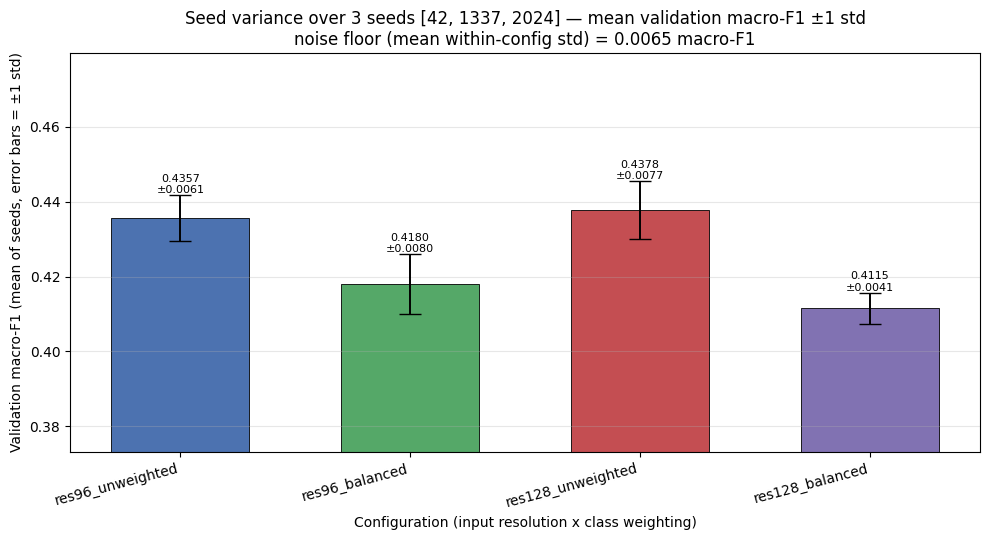

saved: ../plots\nb03_seed_variance.png

Seed-variance repeat (§3b): the same 2x2 grid was retrained over seeds [42, 1337, 2024] using the cached frozen-backbone features (nothing re-extracted), giving 12 runs. Mean within-configuration std of validation macro-F1 = 0.0065; that is the NOISE FLOOR - the smallest validation macro-F1 difference this project may treat as meaningful. Resolution gap = 0.0022 (does NOT exceed 1 std). Weighting gap = 0.0220 (exceeds 1 std). Winner selection was not changed by this section and the final model is still the seed-42 choice res96_unweighted.
saved: ../outputs\run_20260822_175944.json


In [22]:
import matplotlib
import matplotlib.pyplot as plt

# --- (a) nb03_config_comparison.csv, EXTENDED with a `seed` column -----------
# Same schema as the seed-42 grid frame plus `seed`: one row per config per seed.
# §5 rewrites this same file; CONFIG_COMPARISON_EXPORT is what it will write, so
# the 12-row version is what survives on disk.
CONFIG_COMPARISON_EXPORT = seed_df
p_cfg_seeds = os.path.join(OUT_DIR, "nb03_config_comparison.csv")
CONFIG_COMPARISON_EXPORT.to_csv(p_cfg_seeds, index=False)
track_write(p_cfg_seeds)
print("saved:", p_cfg_seeds,
      f"({len(CONFIG_COMPARISON_EXPORT)} rows x {len(CONFIG_COMPARISON_EXPORT.columns)} columns, "
      f"one row per config per seed)")

# --- (b) nb03_seed_variance.csv ---------------------------------------------
seed_variance_out = variance_df.rename(columns={"tag": "config"})[
    ["config", "resolution", "weighting",
     "val_macro_f1_mean", "val_macro_f1_std", "val_macro_f1_min", "val_macro_f1_max",
     "val_accuracy_mean", "val_accuracy_std", "val_accuracy_min", "val_accuracy_max",
     "n_seeds"]
]
p_var = os.path.join(OUT_DIR, "nb03_seed_variance.csv")
seed_variance_out.to_csv(p_var, index=False)
track_write(p_var)
print("saved:", p_var, f"({len(seed_variance_out)} rows)")
print()
print(seed_variance_out.to_string(index=False))

# --- (c) nb03_seed_variance.png: mean val macro-F1 with +/-1 std error bars ---
# Fixed x order so the two factors read left-to-right; no faces in this figure.
_plot_order = [f"res{res}_{w}" for res in RESOLUTIONS for w in WEIGHTINGS]
_vplot = (variance_df.set_index("tag").loc[[t for t in _plot_order if t in set(variance_df["tag"])]]
          .reset_index())
_SEED_VAR_COLORS = {
    "res96_unweighted":  "#4C72B0",
    "res96_balanced":    "#55A868",
    "res128_unweighted": "#C44E52",
    "res128_balanced":   "#8172B2",
}
_cycle = matplotlib.rcParams["axes.prop_cycle"].by_key()["color"]

p_seedvar = os.path.join(PLOT_DIR, "nb03_seed_variance.png")
fig, ax = plt.subplots(figsize=(10, 5.5))
_x = np.arange(len(_vplot))
_colors = [_SEED_VAR_COLORS.get(t, _cycle[i % len(_cycle)]) for i, t in enumerate(_vplot["tag"])]
ax.bar(_x, _vplot["val_macro_f1_mean"], 0.6,
       yerr=_vplot["val_macro_f1_std"], capsize=8,
       color=_colors, edgecolor="black", linewidth=0.6,
       error_kw={"ecolor": "black", "elinewidth": 1.4})
for xi, (m, s) in enumerate(zip(_vplot["val_macro_f1_mean"], _vplot["val_macro_f1_std"])):
    ax.text(xi, m + s, f"{m:.4f}\n±{s:.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(_x)
ax.set_xticklabels(_vplot["tag"], rotation=15, ha="right")
ax.set_xlabel("Configuration (input resolution x class weighting)")
ax.set_ylabel("Validation macro-F1 (mean of seeds, error bars = ±1 std)")
ax.set_title(f"Seed variance over {len(SEEDS)} seeds {SEEDS} — "
             f"mean validation macro-F1 ±1 std\n"
             f"noise floor (mean within-config std) = {NOISE_FLOOR_MACRO_F1:.4f} macro-F1")
_ymax = float((_vplot["val_macro_f1_mean"] + _vplot["val_macro_f1_std"]).max())
_ymin = float((_vplot["val_macro_f1_mean"] - _vplot["val_macro_f1_std"]).min())
_pad = max(0.02, (_ymax - _ymin) * 0.9)
ax.set_ylim(max(0.0, _ymin - _pad), _ymax + _pad)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(p_seedvar, dpi=150, bbox_inches="tight")
track_write(p_seedvar)
plt.show()
print("saved:", p_seedvar)

# --- (d) run metadata: seed-variance summary + the noise floor ----------------
# Kept in its own dict as well as merged into RUN["metrics"], because §5 reassigns
# RUN["metrics"] wholesale and re-merges this block from SEED_VARIANCE_METRICS.
SEED_VARIANCE_METRICS = {
    "seed_variance": {
        "seeds": [int(s) for s in SEEDS],
        "n_seeds": int(len(SEEDS)),
        "n_runs": int(len(seed_results)),
        "seed_grid_seconds": SEED_GRID_SECONDS,
        "features_reextracted": False,
        "selection_changed": False,
        "per_config": [
            {
                "config": str(v["config"]),
                "resolution": int(v["resolution"]),
                "weighting": str(v["weighting"]),
                "val_macro_f1_mean": float(v["val_macro_f1_mean"]),
                "val_macro_f1_std": float(v["val_macro_f1_std"]),
                "val_macro_f1_min": float(v["val_macro_f1_min"]),
                "val_macro_f1_max": float(v["val_macro_f1_max"]),
                "val_accuracy_mean": float(v["val_accuracy_mean"]),
                "val_accuracy_std": float(v["val_accuracy_std"]),
                "val_accuracy_min": float(v["val_accuracy_min"]),
                "val_accuracy_max": float(v["val_accuracy_max"]),
                "n_seeds": int(v["n_seeds"]),
            }
            for _, v in seed_variance_out.iterrows()
        ],
        "resolution_gap_macro_f1": RES_GAP_SEEDS,
        "resolution_gap_exceeds_noise_floor": RES_GAP_EXCEEDS_NOISE,
        "weighting_gap_macro_f1": WGT_GAP_SEEDS,
        "weighting_gap_exceeds_noise_floor": WGT_GAP_EXCEEDS_NOISE,
    },
    "noise_floor_macro_f1": NOISE_FLOOR_MACRO_F1,
    "noise_floor_accuracy": NOISE_FLOOR_ACCURACY,
}
RUN["metrics"].update(SEED_VARIANCE_METRICS)

SEED_VARIANCE_NOTE = (
    f"Seed-variance repeat (§3b): the same 2x2 grid was retrained over seeds {SEEDS} using the "
    f"cached frozen-backbone features (nothing re-extracted), giving {len(seed_results)} runs. "
    f"Mean within-configuration std of validation macro-F1 = {NOISE_FLOOR_MACRO_F1:.4f}; that is "
    "the NOISE FLOOR - the smallest validation macro-F1 difference this project may treat as "
    f"meaningful. Resolution gap = {RES_GAP_SEEDS:.4f} "
    f"({'exceeds' if RES_GAP_EXCEEDS_NOISE else 'does NOT exceed'} 1 std). Weighting gap = "
    f"{WGT_GAP_SEEDS:.4f} ({'exceeds' if WGT_GAP_EXCEEDS_NOISE else 'does NOT exceed'} 1 std). "
    "Winner selection was not changed by this section and the final model is still the seed-42 "
    f"choice {WINNING_TAG}."
)
print()
print(SEED_VARIANCE_NOTE)

# save_run() re-called here so the seed-variance block is on disk even if the run
# stops before §5. The run JSON is byte-tracked once, in §5, not here.
run_path = save_run(RUN)

## 4. Final model — a single end-to-end inference graph

The winning head is retrained from the same seed on the winning resolution's cached features (this
reproduces the grid run exactly rather than reusing an object that has already been mutated by
`restore_best_weights`), and is then **welded onto the frozen backbone** to form one model:

```
Input(res, res, 3) -> frozen MobileNetV2 (pooling=avg) -> Dropout -> Dense(7, softmax)
```

Saving the end-to-end graph rather than the bare head matters for what comes next. Notebook 04 needs
to unfreeze the top backbone blocks and continue training; notebook 07 needs a single graph to hand
to the TFLite converter. Neither can do that with a 1280→7 head plus a note saying "attach a
backbone". The `.keras` format stores architecture and weights together, so notebook 04's first line
can be `load_model(...)` followed by `backbone.trainable = True`.

The backbone stays `trainable=False` in the saved artifact — that is the honest record of what this
notebook actually trained.

In [23]:
# --- retrain the winning head from the same seed -----------------------------
print(f"Retraining the winning configuration: {WINNING_TAG}")
x_tr_w = np.load(FEATURE_CACHE[WINNING_RESOLUTION]["train"]).astype(np.float32)
x_va_w = np.load(FEATURE_CACHE[WINNING_RESOLUTION]["val"]).astype(np.float32)

# train_one_config() returns metrics but not the model object, so the retrain is done
# inline here with the identical seed, hyperparameters and callback order. Because
# build_head() re-seeds before constructing the layers, this reproduces the winning
# grid run rather than merely resembling it.
final_head = build_head(N_CLASSES, seed=RUN["random_seed"])
_f1_cb = MacroF1Callback(x_va_w, y_val, verbose=True)
_early = tf.keras.callbacks.EarlyStopping(
    monitor="val_macro_f1", mode="max",
    patience=HEAD_HP["early_stopping"]["patience"],
    restore_best_weights=True, verbose=1,
)
final_head.fit(
    x_tr_w, y_train,
    validation_data=(x_va_w, y_val),
    epochs=HEAD_HP["max_epochs"],
    batch_size=HEAD_HP["batch_size"],
    class_weight=CLASS_WEIGHT_DICT if WINNING_WEIGHTING == "balanced" else None,
    callbacks=[_f1_cb, _early],
    verbose=2,
)

# metrics of the object we are actually about to save
_probs_final = final_head.predict(x_va_w, batch_size=512, verbose=0)
_preds_final = np.argmax(_probs_final, axis=1)
FINAL_VAL_ACC = float(accuracy_score(y_val, _preds_final))
FINAL_VAL_MACRO_F1 = float(f1_score(y_val, _preds_final, average="macro", zero_division=0))
FINAL_REPORT = classification_report(
    y_val, _preds_final, labels=list(range(N_CLASSES)),
    target_names=CLASS_NAMES, output_dict=True, zero_division=0,
)
print()
print(f"Final saved head: val_accuracy={FINAL_VAL_ACC:.4f}  val_macro_f1={FINAL_VAL_MACRO_F1:.4f}")

# --- weld head onto the frozen backbone -> one end-to-end inference model ----
final_backbone = build_backbone(WINNING_RESOLUTION)
final_backbone.trainable = False

inputs = tf.keras.Input(shape=(WINNING_RESOLUTION, WINNING_RESOLUTION, 3), name="image")
embedding = final_backbone(inputs, training=False)
outputs = final_head(embedding)
end_to_end = tf.keras.Model(
    inputs, outputs, name=f"fer_mobilenetv2_frozen_{WINNING_RESOLUTION}"
)

print()
print("=" * 70)
print("END-TO-END MODEL SUMMARY")
print("=" * 70)
end_to_end.summary()

total_params        = int(end_to_end.count_params())
trainable_params    = int(sum(int(np.prod(v.shape)) for v in end_to_end.trainable_weights))
nontrainable_params = int(sum(int(np.prod(v.shape)) for v in end_to_end.non_trainable_weights))
print()
print(f"Total parameters:         {total_params:,}")
print(f"Trainable parameters:     {trainable_params:,}  (the head only — backbone is frozen)")
print(f"Non-trainable parameters: {nontrainable_params:,}")

# --- equivalence check: end-to-end vs (cached features -> head) --------------
# Proves the saved graph reproduces the metrics computed from the cache, i.e. the
# float16 cache round-trip and the tf.data pipeline are faithful.
_n_check = min(256, len(val_paths))
_check_ds = make_image_dataset(val_paths[:_n_check], WINNING_RESOLUTION)
_e2e_probs = end_to_end.predict(_check_ds, verbose=0)
_max_abs_diff = float(np.max(np.abs(_e2e_probs - _probs_final[:_n_check])))
_agree = float(np.mean(np.argmax(_e2e_probs, axis=1) == _preds_final[:_n_check]))
print()
print(f"Equivalence check on {_n_check} validation images "
      f"(end-to-end graph vs cached-feature head):")
print(f"  max |prob difference| = {_max_abs_diff:.6f}")
print(f"  argmax agreement      = {_agree:.4f}")
print("  (small non-zero differences are expected: the cache is float16.)")

# --- save --------------------------------------------------------------------
MODEL_FILENAME = f"fer_mobilenetv2_frozen_{WINNING_RESOLUTION}.keras"
MODEL_PATH = os.path.join(MODELS_DIR, MODEL_FILENAME)
end_to_end.save(MODEL_PATH)
_msize = track_write(MODEL_PATH)
RUN["model_version"] = MODEL_FILENAME
print()
print(f"saved: {MODEL_PATH} ({_msize / 1e6:.1f} MB)")
print(f'RUN["model_version"] = {RUN["model_version"]!r}')

del x_tr_w, x_va_w

Retraining the winning configuration: res96_unweighted
Epoch 1/100
    epoch   1: val_macro_f1=0.3401  val_acc=0.4107
106/106 - 1s - 11ms/step - accuracy: 0.3159 - loss: 1.8715 - val_accuracy: 0.4107 - val_loss: 1.5327 - val_macro_f1: 0.3401
Epoch 2/100
    epoch   2: val_macro_f1=0.3615  val_acc=0.4402
106/106 - 1s - 6ms/step - accuracy: 0.3967 - loss: 1.5896 - val_accuracy: 0.4402 - val_loss: 1.4562 - val_macro_f1: 0.3615
Epoch 3/100
    epoch   3: val_macro_f1=0.3816  val_acc=0.4603
106/106 - 1s - 5ms/step - accuracy: 0.4282 - loss: 1.4979 - val_accuracy: 0.4603 - val_loss: 1.4165 - val_macro_f1: 0.3816
Epoch 4/100
    epoch   4: val_macro_f1=0.3935  val_acc=0.4670
106/106 - 1s - 6ms/step - accuracy: 0.4456 - loss: 1.4536 - val_accuracy: 0.4670 - val_loss: 1.4062 - val_macro_f1: 0.3935
Epoch 5/100
    epoch   5: val_macro_f1=0.4047  val_acc=0.4745
106/106 - 1s - 6ms/step - accuracy: 0.4591 - loss: 1.4230 - val_accuracy: 0.4745 - val_loss: 1.3942 - val_macro_f1: 0.4047
Epoch 6/100
  

Model: "fer_mobilenetv2_frozen_96"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_96 (Functional)     │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fer_head (Sequential)                │ (None, 7)                   │           8,967 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total parameters:         2,266,951
Trainable parameters:     8,967  (the head only — backbone is frozen)
Non-trainable parameters: 2,257,984

Equivalence check on 256 validation images (end-to-end graph vs cached-feature head):
  max |prob difference| = 0.000173
  argmax agreement      = 1.0000
  (small non-zero differences are expected: the cache is float16.)

saved: ../models\fer_mobilenetv2_frozen_96.keras (9.7 MB)
RUN["model_version"] = 'fer_mobilenetv2_frozen_96.keras'


## 5. Artifacts

Three CSVs plus the run-metadata JSON, all into `OUT_DIR`.

> **`nb03_val_probabilities.csv` — raw material, deliberately unthresholded.** This file holds the
> full 7-way softmax vector for every validation sample under the winning model, alongside the true
> label and the file basename. **No threshold, no cut-off, and no smoothing has been applied to it,
> and none is chosen anywhere in this notebook.** The application-level operating point
> (`τ_face_min`), the temporal smoothing window (`N_smooth`), the 7→3 mood mapping, and any
> quantization scheme are all decisions this notebook has no business making — they belong to the
> Tech Lead and the mood-state spec. What notebook 03 owes them is *evidence*, so this file exists
> to let that sweep be run later, over real measured probabilities, without retraining anything.

In [24]:
written_before = bucket_bytes(_WRITTEN_FILES)

# --- (a) 4-way configuration grid -------------------------------------------
p_cfg = os.path.join(OUT_DIR, "nb03_config_comparison.csv")
# §3b extends this table with a `seed` column (one row per config per seed) and
# publishes it as CONFIG_COMPARISON_EXPORT. Falls back to the seed-42 grid frame
# if §3b was not run, so this cell behaves exactly as before without it.
_cfg_export = globals().get("CONFIG_COMPARISON_EXPORT", config_df)
_cfg_export.to_csv(p_cfg, index=False)
track_write(p_cfg)
print("saved:", p_cfg, f"({len(_cfg_export)} rows x {len(_cfg_export.columns)} columns)")

# --- (b) per-sample VAL probabilities for the winner, UNTHRESHOLDED ----------
assert_no_test(val_paths, label="val probability export")
prob_df = pd.DataFrame({
    "basename": val_basenames,
    "true_label": y_val,
    "true_class": [CLASS_NAMES[i] for i in y_val],
    "predicted_label": _preds_final,
    "predicted_class": [CLASS_NAMES[i] for i in _preds_final],
})
for i, c in enumerate(CLASS_NAMES):
    prob_df[f"prob_{c}"] = _probs_final[:, i]

_prob_cols = [f"prob_{c}" for c in CLASS_NAMES]
_rowsums = prob_df[_prob_cols].to_numpy().sum(axis=1)
assert np.allclose(_rowsums, 1.0, atol=1e-4), "softmax rows do not sum to 1"
assert not prob_df["basename"].str.startswith("PrivateTest_").any(), \
    "a PrivateTest_ sample reached the probability export"

p_prob = os.path.join(OUT_DIR, "nb03_val_probabilities.csv")
prob_df.to_csv(p_prob, index=False)
track_write(p_prob)
print("saved:", p_prob, f"({len(prob_df)} rows — VAL only, NO threshold applied)")

# --- (c) per-class metrics for the winner ------------------------------------
per_class_rows = []
for c in CLASS_NAMES:
    r = FINAL_REPORT[c]
    per_class_rows.append({
        "class": c,
        "label": CLASS_TO_IDX[c],
        "precision": float(r["precision"]),
        "recall": float(r["recall"]),
        "f1": float(r["f1-score"]),
        "support": int(r["support"]),
    })
per_class_df = pd.DataFrame(per_class_rows)
p_pc = os.path.join(OUT_DIR, "nb03_per_class_metrics.csv")
per_class_df.to_csv(p_pc, index=False)
track_write(p_pc)
print("saved:", p_pc)
print()
print("Winning model — per-class validation metrics:")
print(per_class_df.to_string(index=False))

# --- (d) run metadata --------------------------------------------------------
RUN["hyperparameters"] = {
    **HEAD_HP,
    "resolutions_searched": RESOLUTIONS,
    "weightings_searched": WEIGHTINGS,
    "class_weights_balanced": CLASS_WEIGHT_DICT,
    "chosen_resolution": WINNING_RESOLUTION,
    "chosen_weighting": WINNING_WEIGHTING,
    "selection_criterion": "highest validation macro-F1",
    "feature_cache_dtype": "float16 (cast to float32 for training)",
    "extraction_batch_size": EXTRACT_BATCH,
}

RUN["metrics"] = {
    "n_train": int(n_train_measured),
    "n_val": int(n_val_measured),
    "val_accuracy": FINAL_VAL_ACC,
    "val_macro_f1": FINAL_VAL_MACRO_F1,
    "per_class": {
        c: {
            "precision": float(FINAL_REPORT[c]["precision"]),
            "recall": float(FINAL_REPORT[c]["recall"]),
            "f1": float(FINAL_REPORT[c]["f1-score"]),
            "support": int(FINAL_REPORT[c]["support"]),
        }
        for c in CLASS_NAMES
    },
    "grid": [
        {
            "resolution": r["resolution"],
            "weighting": r["weighting"],
            "best_epoch": r["best_epoch"],
            "val_accuracy": r["val_accuracy"],
            "val_macro_f1": r["val_macro_f1"],
        }
        for r in results
    ],
    "feature_extraction_seconds": {
        f"res{t['resolution']}_{t['split']}": t["elapsed_s"] for t in EXTRACTION_TIMING
    },
    "test_split_used": False,
}

# RUN["metrics"] is reassigned wholesale just above, which would drop the §3b
# seed-variance block and the measured noise floor. Merge them back in (no-op
# if §3b was not run).
if "SEED_VARIANCE_METRICS" in globals():
    RUN["metrics"].update(SEED_VARIANCE_METRICS)

RUN["notes"] = (
    "Two decisions were taken in this notebook, both by measurement on VALIDATION data only; "
    "the TEST/PrivateTest split was dropped from the manifest before any array was built and was "
    "never loaded, indexed, or evaluated. "
    f"DECISION 1 - input resolution = {WINNING_RESOLUTION}: chosen because it gave the higher mean "
    f"validation macro-F1 across both weighting arms (spread between the two resolutions = "
    f"{RES_EFFECT:.4f} macro-F1). "
    f"DECISION 2 - class weighting = {WINNING_WEIGHTING}: chosen because it gave the higher mean "
    f"validation macro-F1 across both resolutions (spread between the two weightings = "
    f"{WGT_EFFECT:.4f} macro-F1); mean disgust recall was {_dis_unw:.4f} unweighted vs "
    f"{_dis_bal:.4f} balanced. "
    f"Winner {WINNING_TAG} beat the runner-up {runner_up['tag']} by {margin:+.4f} macro-F1. "
    "Backbone frozen throughout; no augmentation (incompatible with the cached-embedding design - "
    "see notebook 04), no resampling, no confidence threshold, no temporal smoothing, no 7->3 mood "
    "mapping, no quantization. nb03_val_probabilities.csv is raw unthresholded material for the "
    "later tau_face_min sweep, which this notebook does not perform."
)

if "SEED_VARIANCE_NOTE" in globals():
    RUN["notes"] = RUN["notes"] + " " + SEED_VARIANCE_NOTE

run_path = save_run(RUN)
track_write(run_path)

written_after = bucket_bytes(_WRITTEN_FILES)
print()
print(f"Artifact bytes written by this section: {written_after - written_before}")

saved: ../outputs\nb03_config_comparison.csv (12 rows x 37 columns)
saved: ../outputs\nb03_val_probabilities.csv (3589 rows — VAL only, NO threshold applied)
saved: ../outputs\nb03_per_class_metrics.csv

Winning model — per-class validation metrics:
   class  label  precision   recall       f1  support
   angry      0   0.379562 0.334047 0.355353      467
 disgust      1   0.480000 0.214286 0.296296       56
    fear      2   0.361564 0.223790 0.276463      496
   happy      3   0.638889 0.616760 0.627629      895
 neutral      4   0.383425 0.571664 0.458995      607
     sad      5   0.391557 0.411945 0.401493      653
surprise      6   0.687179 0.645783 0.665839      415
saved: ../outputs\run_20260822_175944.json

Artifact bytes written by this section: 452111


## 6. Plots

Three figures, all `dpi=150`, all with labelled axes and titles. **None of them contains a face** —
this notebook plots curves and bar charts only, so every figure here is safe to commit without the
`review_` prefix that notebook 02 used for its face-bearing grids.

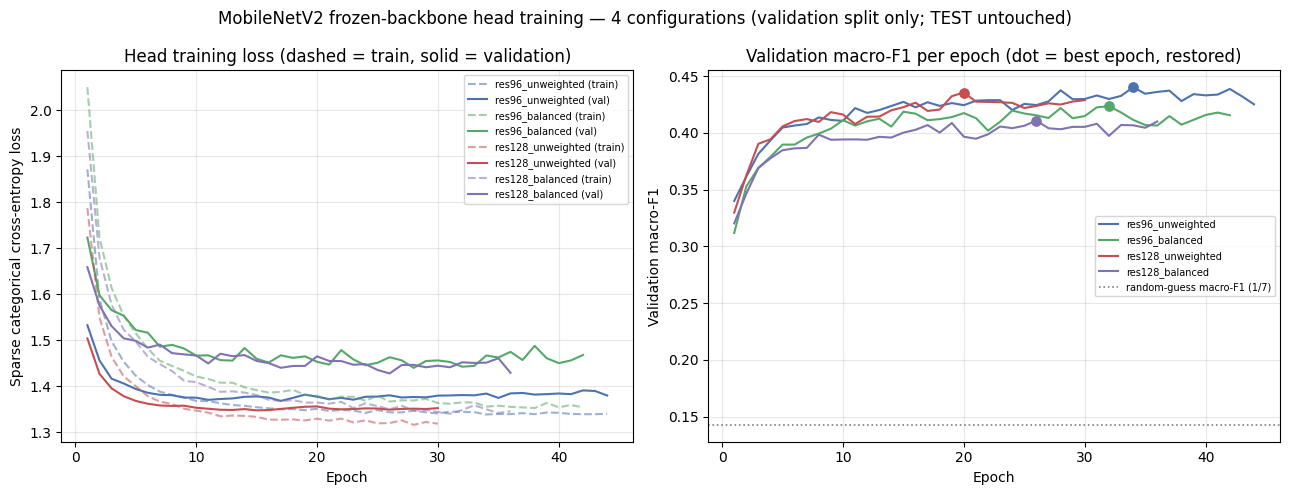

saved: ../plots\nb03_training_curves.png


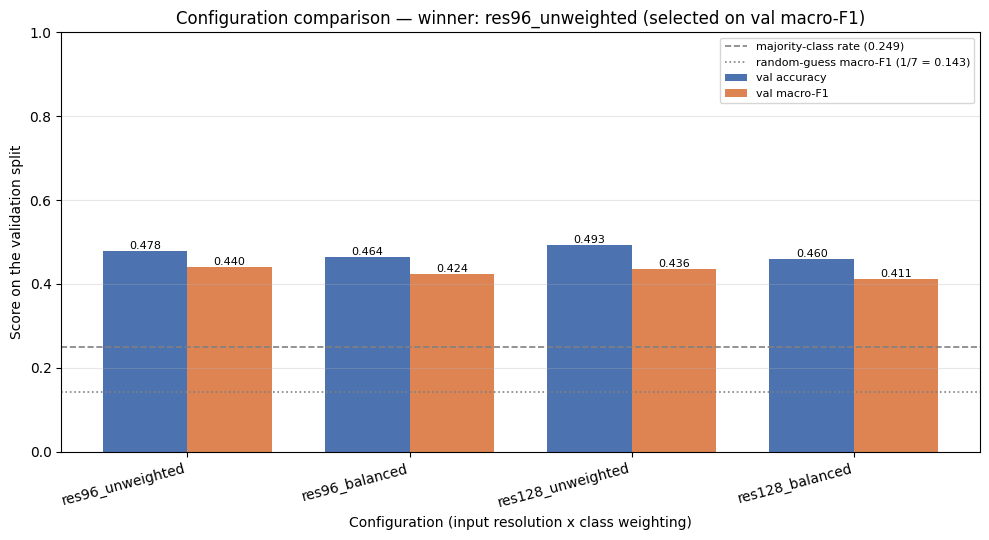

saved: ../plots\nb03_config_comparison.png


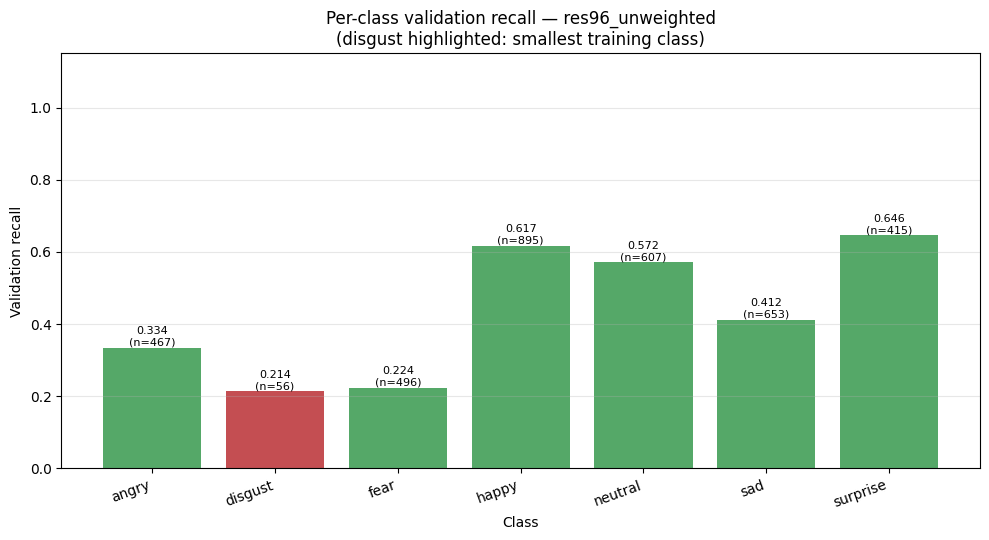

saved: ../plots\nb03_per_class_recall.png


In [25]:
import matplotlib
import matplotlib.pyplot as plt

CONFIG_COLORS = {
    "res96_unweighted":  "#4C72B0",
    "res96_balanced":    "#55A868",
    "res128_unweighted": "#C44E52",
    "res128_balanced":   "#8172B2",
}
_fallback_cycle = matplotlib.rcParams["axes.prop_cycle"].by_key()["color"]

def color_for(tag, i):
    return CONFIG_COLORS.get(tag, _fallback_cycle[i % len(_fallback_cycle)])

# --- (1) training curves -----------------------------------------------------
p1 = os.path.join(PLOT_DIR, "nb03_training_curves.png")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, r in enumerate(results):
    col = color_for(r["tag"], i)
    ep = np.arange(1, len(r["history"]["loss"]) + 1)
    axes[0].plot(ep, r["history"]["loss"], color=col, linestyle="--", alpha=0.55,
                 label=f"{r['tag']} (train)")
    axes[0].plot(ep, r["history"]["val_loss"], color=col, linestyle="-",
                 label=f"{r['tag']} (val)")
    axes[1].plot(ep, r["history"]["val_macro_f1"], color=col, linestyle="-", label=r["tag"])
    axes[1].scatter([r["best_epoch"]],
                    [r["history"]["val_macro_f1"][r["best_epoch"] - 1]],
                    color=col, marker="o", s=45, zorder=5)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse categorical cross-entropy loss")
axes[0].set_title("Head training loss (dashed = train, solid = validation)")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

axes[1].axhline(1.0 / N_CLASSES, color="grey", linestyle=":", linewidth=1.2,
                label=f"random-guess macro-F1 (1/{N_CLASSES})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation macro-F1")
axes[1].set_title("Validation macro-F1 per epoch (dot = best epoch, restored)")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

fig.suptitle("MobileNetV2 frozen-backbone head training — 4 configurations "
             "(validation split only; TEST untouched)")
plt.tight_layout()
plt.savefig(p1, dpi=150, bbox_inches="tight")
track_write(p1)
plt.show()
print("saved:", p1)

# --- (2) grouped bars: val accuracy vs val macro-F1 --------------------------
p2 = os.path.join(PLOT_DIR, "nb03_config_comparison.png")
fig, ax = plt.subplots(figsize=(10, 5.5))
xpos = np.arange(len(config_df))
width = 0.38
ax.bar(xpos - width / 2, config_df["val_accuracy"], width,
       label="val accuracy", color="#4C72B0")
ax.bar(xpos + width / 2, config_df["val_macro_f1"], width,
       label="val macro-F1", color="#DD8452")
for x, (a, f) in enumerate(zip(config_df["val_accuracy"], config_df["val_macro_f1"])):
    ax.text(x - width / 2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(x + width / 2, f, f"{f:.3f}", ha="center", va="bottom", fontsize=8)

_maj = float(np.bincount(y_val, minlength=N_CLASSES).max()) / len(y_val)
ax.axhline(_maj, color="grey", linestyle="--", linewidth=1.2,
           label=f"majority-class rate ({_maj:.3f})")
ax.axhline(1.0 / N_CLASSES, color="grey", linestyle=":", linewidth=1.2,
           label=f"random-guess macro-F1 (1/{N_CLASSES} = {1.0 / N_CLASSES:.3f})")

ax.set_xticks(xpos)
ax.set_xticklabels(config_df["tag"], rotation=15, ha="right")
ax.set_xlabel("Configuration (input resolution x class weighting)")
ax.set_ylabel("Score on the validation split")
ax.set_title(f"Configuration comparison — winner: {WINNING_TAG} (selected on val macro-F1)")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(p2, dpi=150, bbox_inches="tight")
track_write(p2)
plt.show()
print("saved:", p2)

# --- (3) per-class recall for the winner -------------------------------------
p3 = os.path.join(PLOT_DIR, "nb03_per_class_recall.png")
fig, ax = plt.subplots(figsize=(10, 5.5))
_colors = ["#C44E52" if c == "disgust" else "#55A868" for c in per_class_df["class"]]
bars = ax.bar(per_class_df["class"], per_class_df["recall"], color=_colors)
for b, rec, sup in zip(bars, per_class_df["recall"], per_class_df["support"]):
    ax.text(b.get_x() + b.get_width() / 2, rec, f"{rec:.3f}\n(n={sup})",
            ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Class")
ax.set_ylabel("Validation recall")
ax.set_title(f"Per-class validation recall — {WINNING_TAG}\n"
             f"(disgust highlighted: smallest training class)")
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
for tick in ax.get_xticklabels():
    tick.set_rotation(20)
    tick.set_ha("right")
plt.tight_layout()
plt.savefig(p3, dpi=150, bbox_inches="tight")
track_write(p3)
plt.show()
print("saved:", p3)

## 7. Sanity gates

Four checks. Each prints PASS or FAIL explicitly; nothing here passes silently, and a failure is
banner-printed rather than swallowed, so a broken run cannot be mistaken for a good one at a glance.

1. **Validation accuracy beats the majority-class rate.** The majority rate is computed at runtime
   from `y_val` — a classifier that always answered with the largest class would score it, so
   failing this means the model has learned nothing useful at all.
2. **Validation macro-F1 beats 1/7.** The floor for uninformative predictions over 7 classes.
3. **`disgust` recall is reported for every configuration.** It has the fewest training images by a
   wide margin, so it is the sharpest single indicator of whether class weighting did what it was
   supposed to.
4. **No TEST/PrivateTest row ever entered any array.** Re-asserted here from scratch over every path
   list, the manifest, and the exported probability CSV.

In [26]:
print("=" * 70)
print("SANITY GATES")
print("=" * 70)
gates = {}

# --- gate 1: val accuracy > majority-class rate ------------------------------
_counts = np.bincount(y_val, minlength=N_CLASSES)
majority_idx = int(np.argmax(_counts))
majority_rate = float(_counts[majority_idx]) / float(len(y_val))
g1 = FINAL_VAL_ACC > majority_rate
gates["val_accuracy_beats_majority_class"] = g1
print(f"[{'PASS' if g1 else 'FAIL'}] gate 1: val accuracy > majority-class rate")
print(f"         majority class = '{CLASS_NAMES[majority_idx]}' "
      f"({int(_counts[majority_idx])}/{len(y_val)} = {majority_rate:.4f})")
print(f"         val accuracy   = {FINAL_VAL_ACC:.4f}   margin = {FINAL_VAL_ACC - majority_rate:+.4f}")

# --- gate 2: val macro-F1 > 1/7 ----------------------------------------------
f1_floor = 1.0 / N_CLASSES
g2 = FINAL_VAL_MACRO_F1 > f1_floor
gates["val_macro_f1_beats_random"] = g2
print()
print(f"[{'PASS' if g2 else 'FAIL'}] gate 2: val macro-F1 > 1/{N_CLASSES}")
print(f"         floor        = {f1_floor:.4f}")
print(f"         val macro-F1 = {FINAL_VAL_MACRO_F1:.4f}   margin = {FINAL_VAL_MACRO_F1 - f1_floor:+.4f}")

# --- gate 3: disgust recall reported for EVERY config -------------------------
print()
print("[INFO] gate 3: disgust recall for every configuration in the grid")
_disgust_reported = []
for r in results:
    rec = r["per_class"]["disgust"]["recall"]
    _disgust_reported.append(rec)
    print(f"         {r['tag']:<20} recall={rec:.4f}  "
          f"precision={r['per_class']['disgust']['precision']:.4f}  "
          f"f1={r['per_class']['disgust']['f1']:.4f}  "
          f"support={r['per_class']['disgust']['support']}")
print(f"         winner ({WINNING_TAG}) disgust recall = "
      f"{FINAL_REPORT['disgust']['recall']:.4f}")
g3 = len(_disgust_reported) == len(results) and all(np.isfinite(_disgust_reported))
gates["disgust_recall_reported_for_all_configs"] = g3
print(f"[{'PASS' if g3 else 'FAIL'}] gate 3: disgust recall present for all "
      f"{len(results)} configurations")

# --- gate 4: no TEST/PrivateTest anywhere ------------------------------------
print()
try:
    assert_no_test(train_paths, val_paths, label="gate 4 path arrays")
    assert "TEST" not in set(manifest["split_group"]), "TEST rows present in manifest"
    assert not manifest["basename"].str.startswith("PrivateTest_").any(), \
        "PrivateTest_ basename present in manifest"
    assert not prob_df["basename"].str.startswith("PrivateTest_").any(), \
        "PrivateTest_ basename present in the exported probabilities"
    assert len(train_paths) + len(val_paths) == len(manifest), \
        "path arrays and manifest disagree on row count"
    g4 = True
except AssertionError as e:
    g4 = False
    print("         ", e)
gates["no_test_split_used"] = g4
print(f"[{'PASS' if g4 else 'FAIL'}] gate 4: no TEST/PrivateTest row entered any array")
print(f"         manifest split_groups present: {sorted(set(manifest['split_group']))}")
print(f"         train_paths={len(train_paths)}  val_paths={len(val_paths)}  "
      f"manifest={len(manifest)}")

# --- summary ------------------------------------------------------------------
ALL_GATES_OK = all(gates.values())
print()
print("=" * 70)
if ALL_GATES_OK:
    print("ALL SANITY GATES PASSED.")
else:
    print("!" * 70)
    print("!!  ONE OR MORE SANITY GATES FAILED — do NOT proceed to notebook 04    !!")
    print("!!  until the failure below is understood.                             !!")
    for k, v in gates.items():
        if not v:
            print(f"!!    FAILED: {k}")
    print("!" * 70)
print("=" * 70)

RUN["metrics"]["sanity_gates"] = {k: bool(v) for k, v in gates.items()}
RUN["metrics"]["majority_class_rate_val"] = majority_rate
RUN["metrics"]["macro_f1_floor"] = f1_floor
run_path = save_run(RUN)   # rewrite with the gate results included

SANITY GATES
[PASS] gate 1: val accuracy > majority-class rate
         majority class = 'happy' (895/3589 = 0.2494)
         val accuracy   = 0.4778   margin = +0.2285

[PASS] gate 2: val macro-F1 > 1/7
         floor        = 0.1429
         val macro-F1 = 0.4403   margin = +0.2974

[INFO] gate 3: disgust recall for every configuration in the grid
         res96_unweighted     recall=0.2143  precision=0.4800  f1=0.2963  support=56
         res96_balanced       recall=0.6429  precision=0.1314  f1=0.2182  support=56
         res128_unweighted    recall=0.1250  precision=0.5833  f1=0.2059  support=56
         res128_balanced      recall=0.5893  precision=0.1071  f1=0.1813  support=56
         winner (res96_unweighted) disgust recall = 0.2143
[PASS] gate 3: disgust recall present for all 4 configurations

[PASS] gate 4: no TEST/PrivateTest row entered any array
         manifest split_groups present: ['TRAIN', 'VAL']
         train_paths=26901  val_paths=3589  manifest=30490

ALL SANITY 

## 8. Byte report

Two buckets, printed separately because they have different budgets and different lifetimes. The
**artifact** bucket (`outputs/`, `plots/`, `models/`) is committed evidence. The **cache** bucket
(`data/processed/`) is regenerable — deleting it costs only the re-extraction time reported in §2,
and the notebook rebuilds it automatically on the next run.

In [27]:
print("=" * 70)
print("ARTIFACT BYTES (OUT_DIR / PLOT_DIR / MODELS_DIR)")
print("=" * 70)
artifact_df = pd.DataFrame(_WRITTEN_FILES, columns=["path", "bytes"])
print(artifact_df.to_string(index=False))
artifact_total = bucket_bytes(_WRITTEN_FILES)
print(f"\nARTIFACT TOTAL: {artifact_total} bytes ({artifact_total / 1e6:.2f} MB)")

print()
print("=" * 70)
print("FEATURE-CACHE BYTES (PROCESSED_DIR — regenerable, gitignored)")
print("=" * 70)
cache_df = pd.DataFrame(_CACHE_FILES, columns=["path", "bytes"])
print(cache_df.to_string(index=False))
cache_total = bucket_bytes(_CACHE_FILES)
print(f"\nCACHE TOTAL: {cache_total} bytes ({cache_total / 1e6:.2f} MB)")

grand_total = artifact_total + cache_total
print()
print("=" * 70)
print(f"TOTAL BYTES WRITTEN BY NOTEBOOK 03: {grand_total} ({grand_total / 1e6:.2f} MB)")
print("=" * 70)
print(f"Feature-cache ceiling: {CACHE_BUDGET_BYTES / 1e6:.0f} MB — "
      f"{'WITHIN' if cache_total <= CACHE_BUDGET_BYTES else 'OVER'}")

ARTIFACT BYTES (OUT_DIR / PLOT_DIR / MODELS_DIR)
                                     path   bytes
    ../outputs\nb03_config_comparison.csv    6716
        ../outputs\nb03_seed_variance.csv     941
          ../plots\nb03_seed_variance.png   83216
../models\fer_mobilenetv2_frozen_96.keras 9730709
    ../outputs\nb03_config_comparison.csv    6716
    ../outputs\nb03_val_probabilities.csv  436022
    ../outputs\nb03_per_class_metrics.csv     520
      ../outputs\run_20260822_175944.json    8853
        ../plots\nb03_training_curves.png  201967
      ../plots\nb03_config_comparison.png   79475
       ../plots\nb03_per_class_recall.png   60722

ARTIFACT TOTAL: 10615857 bytes (10.62 MB)

FEATURE-CACHE BYTES (PROCESSED_DIR — regenerable, gitignored)
                                path    bytes
  ../data/processed\labels_train.npy   215336
    ../data/processed\labels_val.npy    28840
 ../data/processed\feat_96_train.npy 68866688
   ../data/processed\feat_96_val.npy  9187968
../data/process

## 9. Download artifacts (Colab only)

On Colab, `OUT_DIR`/`PLOT_DIR`/`MODELS_DIR` live under `/content`, which is not the repo. This zips
everything produced above and triggers a browser download. The feature cache under
`data/processed/` is **excluded** — it is large and fully regenerable. Locally this cell is a no-op:
the files are already sitting in `../outputs`, `../plots`, and `../models`.

In [28]:
if IN_COLAB:
    import shutil

    from google.colab import files as colab_files

    staging = "/content/nb03_artifacts"
    if os.path.isdir(staging):
        shutil.rmtree(staging)
    os.makedirs(staging, exist_ok=True)
    for src, sub in ((OUT_DIR, "outputs"), (PLOT_DIR, "plots"), (MODELS_DIR, "models")):
        shutil.copytree(src, os.path.join(staging, sub))

    archive_path = shutil.make_archive("/content/nb03_artifacts", "zip", staging)
    print("Created archive:", archive_path)
    print()
    print("After downloading, unzip it locally and place:")
    print("  outputs/*  ->  ml/fer/outputs/")
    print("  plots/*    ->  ml/fer/plots/")
    print("  models/*   ->  ml/fer/models/")
    print("into the repo. data/processed/ is NOT included — it is a regenerable feature cache.")
    colab_files.download(archive_path)
else:
    print("Not running on Colab — artifacts were already written directly to:")
    print("  ", OUT_DIR)
    print("  ", PLOT_DIR)
    print("  ", MODELS_DIR)
    print("Nothing to zip/download.")

Not running on Colab — artifacts were already written directly to:
   ../outputs
   ../plots
   ../models
Nothing to zip/download.
